# 07 - Anchoveta Catch and Oceanographic Conditions - Full Analysis

Analyses the relationship between anchoveta catch and oceanographic variables using HYCOM and MODIS data (2015-2024).

**Steps:**
0. Cross-sensor validation - HYCOM temperature vs MODIS SST (KDTree matching, per-cell Pearson r and bias)
1. ENSO classification - attach ONI index and phase labels to the daily dataset
2. Univariate Spearman correlations - pooled and per ENSO phase
3. Weekly aggregation - aggregate daily data to ISO weeks
4. Baseline OLS - log(catch) ~ SST anomaly + log(Chl) + salinity anomaly
5. Quadratic SST - add SST^2 term to the baseline
6. Interactions - SST x Chl and SST x salinity interaction terms
7. ENSO as covariate and stratifier - ONI additive + separate regressions per phase
8. Weekly repeat - steps 4-7 on weekly data; Tobit regression for zero-catch weeks
9. Habitat index - equal-weight and data-driven composite; tercile boxplots
10. Threshold identification - percentile-based cold/warm triggers and payout structure

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr, kruskal
from scipy.spatial import cKDTree
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

OUT   = Path("/home/jupyter-daniela/suyana/peru_production/outputs/")
FEAT  = Path("/home/jupyter-daniela/suyana/peru_production/features/")
PLOTS = Path("/home/jupyter-daniela/peru_catch_modeling/outputs")
PLOTS.mkdir(exist_ok=True)

PROJ = ccrs.PlateCarree()
EXT  = [-90.0, -70.0, -20.0, 0.0]

def add_gridlines(ax):
    gl = ax.gridlines(crs=PROJ, draw_labels=True,
                      linewidth=0.4, color='grey', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

def base_map(ax):
    ax.set_extent(EXT, crs=PROJ)
    ax.add_feature(cfeature.LAND, facecolor='wheat', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=':', zorder=3)
    add_gridlines(ax)

In [2]:
df_raw = pd.read_csv(OUT / 'calas_with_hycom_data.csv')

rename_map = {
    'fecha_cala':           'date',
    'fecha':                'date',
    'temporada':            'season',
    'empresa':              'company',
    'nave':                 'vessel',
    'declarado_tm':         'catch_tm',
    'latitud':              'lat',
    'longitud':             'lon',
    'hycom_temperatura':    'hycom_temp',
    'hycom_salinidad':      'hycom_sal',
    'hycom_temp_anomaly':   'hycom_temp_anom',
    'hycom_temp_anom':      'hycom_temp_anom',
    'chlor_a':              'chl',
    'hycom_salinidad_ref_35': 'hycom_sal_anom_ref35_raw',
    'modis_sst_anomaly':    'modis_sst_anom',
    'modis_sst_anomaly':    'modis_sst_anom',
    'temperatura':          'hycom_temp',
    'salinidad':            'hycom_sal',
    'anom_temp':            'hycom_temp_anom',
    'anom_sal':             'hycom_sal_anom',
    'anom_sal_ref35':       'hycom_sal_anom_ref35_raw',
}
df_raw = df_raw.rename(columns={k:v for k,v in rename_map.items() if k in df_raw.columns})
df_raw['date'] = pd.to_datetime(df_raw['date'])

need = ['hycom_temp_anom','hycom_sal','catch_tm']
df   = df_raw.dropna(subset=need).copy()
df   = df[df['catch_tm'] > 0].copy()

Q1,Q3 = df['catch_tm'].quantile([0.25,0.75])
IQR   = Q3 - Q1
df    = df[(df['catch_tm'] >= Q1-1.5*IQR) & (df['catch_tm'] <= Q3+1.5*IQR)].copy()

df['doy']               = df['date'].dt.dayofyear
sal_clim                = df.groupby('doy')['hycom_sal'].mean()
df['hycom_sal_anom']    = df['hycom_sal'] - df['doy'].map(sal_clim)
df['hycom_sal_anom_ref35'] = df['hycom_sal'] - 35.1

df['log_chl']       = np.log(df['chl'].clip(lower=1e-6))
log_chl_clim        = df.groupby('doy')['log_chl'].mean()
df['log_chl_anom']  = df['log_chl'] - df['doy'].map(log_chl_clim)

df['log_catch'] = np.log(df['catch_tm'])

agg_spec = dict(
    total_catch_tm      =('catch_tm',              'sum'),
    modis_sst_anom      =('modis_sst_anom',         'mean'),
    hycom_temp_anom     =('hycom_temp_anom',         'mean'),
    log_chl_anom        =('log_chl_anom',            'mean'),
    hycom_sal_anom      =('hycom_sal_anom',           'mean'),
    hycom_sal_anom_ref35=('hycom_sal_anom_ref35',     'mean'),
    season              =('season',                 'first'),
)
df = (df.groupby('date').agg(**agg_spec).reset_index())
df['log_catch'] = np.log(df['total_catch_tm'])

print(f"Daily panel: {len(df):,} rows | date range: {df['date'].min().date()} – {df['date'].max().date()}")
print(df[['modis_sst_anom','hycom_temp_anom','log_chl_anom','hycom_sal_anom','total_catch_tm']].describe().round(3))


Daily panel: 1,106 rows | date range: 2015-11-17 – 2024-06-18
       modis_sst_anom  hycom_temp_anom  log_chl_anom  hycom_sal_anom  \
count         818.000         1106.000       557.000        1106.000   
mean           -0.358           -0.073        -0.149          -0.006   
std             1.074            0.775         0.681           0.119   
min            -3.435           -1.707        -2.375          -0.341   
25%            -1.136           -0.597        -0.554          -0.093   
50%            -0.401           -0.203        -0.000           0.003   
75%             0.381            0.348         0.264           0.075   
max             3.059            2.676         1.871           0.323   

       total_catch_tm  
count        1106.000  
mean        15786.288  
std          9664.768  
min            20.000  
25%          8273.500  
50%         15051.500  
75%         22608.500  
max         50820.000  


## Step 0 - Cross-sensor validation (netCDF level)
Verify HYCOM surface temperature against MODIS SST using KDTree nearest-neighbor matching.

In [3]:
hycom_files = sorted(FEAT.glob('hycom_water_temp_daily_*.nc'))
modis_files = sorted(FEAT.glob('sst_daily_*.nc'))
print("HYCOM daily files:", [f.name for f in hycom_files])
print("MODIS SST daily files:", [f.name for f in modis_files])


HYCOM daily files: ['hycom_water_temp_daily_2015.nc', 'hycom_water_temp_daily_2016.nc', 'hycom_water_temp_daily_2017.nc', 'hycom_water_temp_daily_2018.nc', 'hycom_water_temp_daily_2019.nc', 'hycom_water_temp_daily_2020.nc', 'hycom_water_temp_daily_2021.nc', 'hycom_water_temp_daily_2022.nc', 'hycom_water_temp_daily_2023.nc', 'hycom_water_temp_daily_2024.nc']
MODIS SST daily files: ['sst_daily_2015.nc', 'sst_daily_2016.nc', 'sst_daily_2017.nc', 'sst_daily_2018.nc', 'sst_daily_2019.nc', 'sst_daily_2020.nc', 'sst_daily_2021.nc', 'sst_daily_2022.nc', 'sst_daily_2023.nc', 'sst_daily_2024.nc']


sh: 1: getfattr: not found
sh: 1: getfattr: not found


HYCOM: using depth=0.0 m
Common days: 364


Total matched pairs: 8,687,203
Pearson r=0.959  RMSE=0.916°C  Mean bias=-0.537°C


HYCOM cells with r computed: 46,138


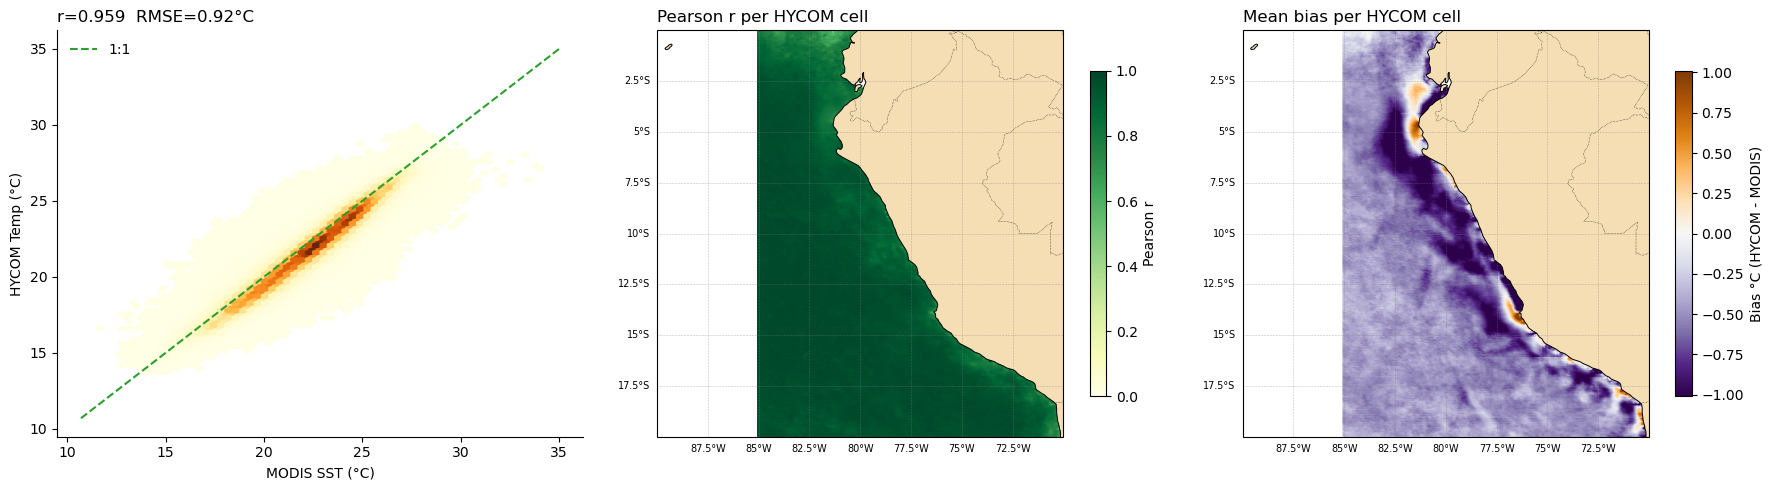

In [4]:
SAMPLE_YEAR = 2021

hf = FEAT / f'hycom_water_temp_daily_{SAMPLE_YEAR}.nc'
mf = FEAT / f'sst_daily_{SAMPLE_YEAR}.nc'

ds_h = xr.open_dataset(hf)
ds_m = xr.open_dataset(mf)

if 'depth' in ds_h.dims:
    depth_vals = ds_h['depth'].values
    ds_h = ds_h.isel(depth=0)
    print(f"HYCOM: using depth={depth_vals[0]} m")

h_lats_raw = ds_h['lat'].values
h_lons_raw = ds_h['lon'].values
h_lons = np.where(h_lons_raw > 180, h_lons_raw - 360, h_lons_raw)
h_lats = h_lats_raw
h_times = pd.to_datetime(ds_h['time'].values)
m_lats  = ds_m['lat'].values
m_lons  = ds_m['lon'].values
m_times = pd.to_datetime(ds_m['time'].values)

hlon2, hlat2 = np.meshgrid(h_lons, h_lats)
tree = cKDTree(np.column_stack([hlon2.ravel(), hlat2.ravel()]))

common_days = sorted(set(h_times) & set(m_times))
print(f"Common days: {len(common_days)}")

n_cells  = len(h_lats) * len(h_lons)
cell_h   = [[] for _ in range(n_cells)]
cell_m   = [[] for _ in range(n_cells)]
pairs_h_all, pairs_m_all = [], []

for day in common_days:
    hidx = np.where(h_times == day)[0][0]
    midx = np.where(m_times == day)[0][0]
    sst_slice = ds_m['sst'].isel(time=midx).values
    valid = np.argwhere(np.isfinite(sst_slice))
    if len(valid) == 0:
        continue
    m_pts = np.column_stack([m_lons[valid[:,1]], m_lats[valid[:,0]]])
    _, nn_idx = tree.query(m_pts)
    h_arr = ds_h['water_temp'].isel(time=hidx).values
    for k in range(len(valid)):
        mv = float(sst_slice[valid[k,0], valid[k,1]])
        ri = nn_idx[k] // len(h_lons)
        ci = nn_idx[k] % len(h_lons)
        hv = float(h_arr[ri, ci])
        if np.isfinite(hv):
            cell_h[nn_idx[k]].append(hv)
            cell_m[nn_idx[k]].append(mv)
            pairs_h_all.append(hv)
            pairs_m_all.append(mv)

ds_h.close(); ds_m.close()

pairs_h_all = np.array(pairs_h_all)
pairs_m_all = np.array(pairs_m_all)
bias_all    = pairs_h_all - pairs_m_all
r_global    = np.corrcoef(pairs_h_all, pairs_m_all)[0,1]
rmse_global = np.sqrt(np.mean(bias_all**2))
print(f"Total matched pairs: {len(pairs_h_all):,}")
print(f"Pearson r={r_global:.3f}  RMSE={rmse_global:.3f}°C  Mean bias={bias_all.mean():+.3f}°C")

map_lons, map_lats, map_r, map_bias = [], [], [], []
for ci in range(n_cells):
    if len(cell_h[ci]) >= 5:
        r_val = np.corrcoef(cell_h[ci], cell_m[ci])[0,1]
        b_val = np.mean(np.array(cell_h[ci]) - np.array(cell_m[ci]))
        row = ci // len(h_lons)
        col = ci % len(h_lons)
        map_lons.append(hlon2[row, col])
        map_lats.append(hlat2[row, col])
        map_r.append(r_val)
        map_bias.append(b_val)

map_lons = np.array(map_lons); map_lats = np.array(map_lats)
map_r    = np.array(map_r);    map_bias  = np.array(map_bias)
print(f"HYCOM cells with r computed: {len(map_r):,}")

TAB = plt.cm.tab10.colors

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
lim = (min(pairs_m_all.min(), pairs_h_all.min())-1,
       max(pairs_m_all.max(), pairs_h_all.max())+1)
ax1.hexbin(pairs_m_all, pairs_h_all, gridsize=60, cmap='YlOrBr', mincnt=1)
ax1.plot(lim, lim, '--', color=TAB[2], lw=1.5, label='1:1')
ax1.set_xlabel('MODIS SST (°C)'); ax1.set_ylabel('HYCOM Temp (°C)')
ax1.set_title(f'r={r_global:.3f}  RMSE={rmse_global:.2f}°C', loc='left')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.legend(frameon=False)

ax2 = fig.add_subplot(1, 3, 2, projection=PROJ)
base_map(ax2)
sc2 = ax2.scatter(map_lons, map_lats, c=map_r,
                  cmap='YlGn', vmin=0, vmax=1,
                  s=6, transform=PROJ, zorder=1)
plt.colorbar(sc2, ax=ax2, label='Pearson r', shrink=0.8)
ax2.set_title('Pearson r per HYCOM cell', loc='left')

ax3 = fig.add_subplot(1, 3, 3, projection=PROJ)
base_map(ax3)
vlim = np.percentile(np.abs(map_bias), 95)
sc3 = ax3.scatter(map_lons, map_lats, c=map_bias,
                  cmap='PuOr_r', vmin=-vlim, vmax=vlim,
                  s=6, transform=PROJ, zorder=1)
plt.colorbar(sc3, ax=ax3, label='Bias °C (HYCOM - MODIS)', shrink=0.8)
ax3.set_title('Mean bias per HYCOM cell', loc='left')

plt.tight_layout()
plt.savefig(PLOTS / 'step0_crossval.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 1 - ENSO classification
Load ONI, classify each month as El Niño / neutral / La Niña, and attach to the daily and weekly datasets.

In [5]:
import urllib.request, io

ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
try:
    with urllib.request.urlopen(ONI_URL, timeout=15) as r:
        raw = r.read().decode()
    oni_df = pd.read_csv(io.StringIO(raw), sep=r'\s+',
                         names=['season_code','year','total','anom'],
                         skiprows=1)
    SEASON_MONTH = {
        'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,
        'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12
    }
    oni_df['month'] = oni_df['season_code'].map(SEASON_MONTH)
    oni_df['date'] = pd.to_datetime(dict(year=oni_df['year'], month=oni_df['month'], day=1))
    oni_df = oni_df[['date','anom']].rename(columns={'anom':'oni_value'}).dropna()
    print(f"ONI loaded from NOAA: {len(oni_df)} months")
except Exception as e:
    print(f"NOAA download failed ({e}). Using embedded 2010–2024 values.")
    oni_records = [
        ('2010-01',0.9),('2010-02',0.6),('2010-03',0.2),('2010-04',-0.2),
        ('2010-05',-0.7),('2010-06',-1.0),('2010-07',-1.2),('2010-08',-1.4),
        ('2010-09',-1.6),('2010-10',-1.7),('2010-11',-1.7),('2010-12',-1.6),
        ('2011-01',-1.5),('2011-02',-1.4),('2011-03',-1.2),('2011-04',-0.8),
        ('2011-05',-0.6),('2011-06',-0.4),('2011-07',-0.5),('2011-08',-0.7),
        ('2011-09',-0.9),('2011-10',-1.1),('2011-11',-1.2),('2011-12',-1.0),
        ('2012-01',-0.8),('2012-02',-0.6),('2012-03',-0.5),('2012-04',-0.3),
        ('2012-05',0.0),('2012-06',0.1),('2012-07',0.1),('2012-08',0.2),
        ('2012-09',0.3),('2012-10',0.2),('2012-11',0.0),('2012-12',-0.2),
        ('2013-01',-0.4),('2013-02',-0.3),('2013-03',-0.2),('2013-04',-0.2),
        ('2013-05',-0.3),('2013-06',-0.4),('2013-07',-0.4),('2013-08',-0.3),
        ('2013-09',-0.2),('2013-10',-0.2),('2013-11',-0.3),('2013-12',-0.4),
        ('2014-01',-0.4),('2014-02',-0.2),('2014-03',0.1),('2014-04',0.3),
        ('2014-05',0.5),('2014-06',0.2),('2014-07',0.1),('2014-08',0.0),
        ('2014-09',0.2),('2014-10',0.4),('2014-11',0.6),('2014-12',0.7),
        ('2015-01',0.6),('2015-02',0.6),('2015-03',0.6),('2015-04',0.8),
        ('2015-05',1.0),('2015-06',1.3),('2015-07',1.6),('2015-08',1.9),
        ('2015-09',2.1),('2015-10',2.4),('2015-11',2.5),('2015-12',2.5),
        ('2016-01',2.3),('2016-02',2.0),('2016-03',1.5),('2016-04',0.8),
        ('2016-05',0.3),('2016-06',-0.1),('2016-07',-0.3),('2016-08',-0.5),
        ('2016-09',-0.7),('2016-10',-0.8),('2016-11',-0.7),('2016-12',-0.6),
        ('2017-01',-0.3),('2017-02',-0.1),('2017-03',0.1),('2017-04',0.2),
        ('2017-05',0.4),('2017-06',0.5),('2017-07',0.2),('2017-08',-0.1),
        ('2017-09',-0.4),('2017-10',-0.7),('2017-11',-1.0),('2017-12',-1.0),
        ('2018-01',-1.0),('2018-02',-0.8),('2018-03',-0.6),('2018-04',-0.4),
        ('2018-05',-0.1),('2018-06',0.1),('2018-07',0.2),('2018-08',0.5),
        ('2018-09',0.8),('2018-10',1.0),('2018-11',0.9),('2018-12',0.8),
        ('2019-01',0.8),('2019-02',0.7),('2019-03',0.8),('2019-04',0.7),
        ('2019-05',0.6),('2019-06',0.5),('2019-07',0.3),('2019-08',0.1),
        ('2019-09',-0.2),('2019-10',-0.3),('2019-11',-0.5),('2019-12',-0.5),
        ('2020-01',0.5),('2020-02',0.5),('2020-03',0.5),('2020-04',0.2),
        ('2020-05',-0.1),('2020-06',-0.4),('2020-07',-0.6),('2020-08',-0.9),
        ('2020-09',-1.0),('2020-10',-1.2),('2020-11',-1.3),('2020-12',-1.2),
        ('2021-01',-1.1),('2021-02',-0.9),('2021-03',-0.7),('2021-04',-0.5),
        ('2021-05',-0.4),('2021-06',-0.1),('2021-07',0.0),('2021-08',-0.2),
        ('2021-09',-0.3),('2021-10',-0.7),('2021-11',-1.0),('2021-12',-1.0),
        ('2022-01',-1.0),('2022-02',-1.1),('2022-03',-0.9),('2022-04',-0.9),
        ('2022-05',-0.8),('2022-06',-0.8),('2022-07',-0.8),('2022-08',-0.9),
        ('2022-09',-0.9),('2022-10',-1.0),('2022-11',-1.0),('2022-12',-0.8),
        ('2023-01',-0.5),('2023-02',-0.1),('2023-03',0.2),('2023-04',0.6),
        ('2023-05',0.9),('2023-06',1.1),('2023-07',1.5),('2023-08',1.8),
        ('2023-09',2.0),('2023-10',2.0),('2023-11',1.9),('2023-12',1.7),
        ('2024-01',1.5),('2024-02',1.2),('2024-03',0.8),('2024-04',0.4),
        ('2024-05',0.0),('2024-06',-0.3),('2024-07',-0.5),('2024-08',-0.7),
        ('2024-09',-0.8),('2024-10',-0.9),('2024-11',-0.9),('2024-12',-0.9),
    ]
    oni_df = pd.DataFrame(oni_records, columns=['ym','oni_value'])
    oni_df['date'] = pd.to_datetime(oni_df['ym'])
    oni_df = oni_df[['date','oni_value']]

THRESH = 0.5
oni_df = oni_df.sort_values('date').reset_index(drop=True)
raw_phase = pd.Series('neutral', index=oni_df.index)
raw_phase[oni_df['oni_value'] >= THRESH]  = 'nino'
raw_phase[oni_df['oni_value'] <= -THRESH] = 'nina'

enso_phase = raw_phase.copy()
for i in range(4, len(raw_phase)):
    window = raw_phase.iloc[i-4:i+1]
    if (window == 'nino').all():
        enso_phase.iloc[i-4:i+1] = 'nino'
    elif (window == 'nina').all():
        enso_phase.iloc[i-4:i+1] = 'nina'
    else:
        if enso_phase.iloc[i] not in ('nino','nina'):
            enso_phase.iloc[i] = 'neutral'

oni_df['enso_phase'] = enso_phase

oni_df['ym'] = oni_df['date'].dt.to_period('M')
df['ym']     = df['date'].dt.to_period('M')
df = df.merge(oni_df[['ym','oni_value','enso_phase']], on='ym', how='left').drop(columns='ym')

print(df[['enso_phase','oni_value']].value_counts('enso_phase'))
print(df[['date','enso_phase','oni_value']].head())


ONI loaded from NOAA: 914 months


enso_phase
neutral    458
nino       331
nina       317
Name: count, dtype: int64
        date enso_phase  oni_value
0 2015-11-17       nino       2.64
1 2015-11-18       nino       2.64
2 2015-11-19       nino       2.64
3 2015-11-20       nino       2.64
4 2015-11-21       nino       2.64



Season ENSO classification:
  season enso_phase  oni_mean
1ra 2016    neutral -0.212105
1ra 2017    neutral  0.305385
1ra 2018    neutral -0.151266
1ra 2019       nino  0.519759
1ra 2020    neutral -0.210274
1ra 2021    neutral -0.364105
1ra 2022       nina -0.819730
1ra 2023       nino  1.218571
1ra 2024    neutral  0.509500
2da 2015       nino  2.684516
2da 2016    neutral -0.401169
2da 2017       nina -0.770000
2da 2018       nino  0.926786
2da 2019       nino  0.618776
2da 2020       nina -1.055676
2da 2021       nina -0.876415
2da 2022       nina -0.631216
2da 2023       nino  1.978933


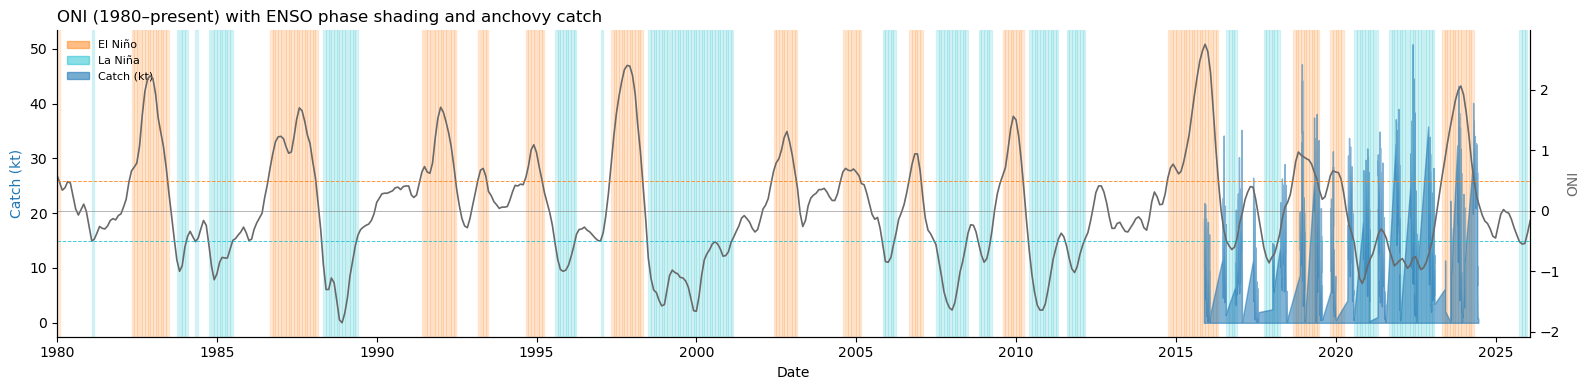

In [6]:
season_enso = (df.groupby('season')
               .agg(enso_phase=('enso_phase', lambda x: x.mode()[0]),
                    oni_mean  =('oni_value',  'mean'))
               .reset_index())
print("\nSeason ENSO classification:")
print(season_enso.to_string(index=False))

TAB = plt.cm.tab10.colors

fig, ax1 = plt.subplots(figsize=(16, 4))
ax2 = ax1.twinx()

oni_plot = oni_df[oni_df['date'] >= '1980-01-01'].copy()

for phase, col in [('nino', TAB[1]), ('nina', TAB[9])]:
    sub = oni_plot[oni_plot['enso_phase'] == phase]
    for _, row in sub.iterrows():
        ax1.axvspan(row['date'], row['date'] + pd.offsets.MonthEnd(1),
                    alpha=0.15, color=col, zorder=0)

ax2.plot(oni_plot['date'], oni_plot['oni_value'],
         color='dimgrey', lw=1.2, label='ONI', zorder=2)
ax2.axhline( 0.5, color=TAB[1], lw=0.7, ls='--', alpha=0.8)
ax2.axhline(-0.5, color=TAB[9], lw=0.7, ls='--', alpha=0.8)
ax2.axhline( 0,   color='grey', lw=0.4)

ax1.fill_between(df['date'], df['total_catch_tm'] / 1e3,
                 alpha=0.55, color=TAB[0], zorder=3, label='Catch (kt)')

ax1.set_xlim(pd.Timestamp('1980-01-01'), oni_plot['date'].max())
ax1.set_xlabel('Date')
ax1.set_ylabel('Catch (kt)', color=TAB[0])
ax2.set_ylabel('ONI', color='dimgrey')
ax1.set_title('ONI (1980–present) with ENSO phase shading and anchovy catch', loc='left')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

handles = [mpatches.Patch(color=TAB[1], alpha=0.5, label='El Niño'),
           mpatches.Patch(color=TAB[9], alpha=0.5, label='La Niña'),
           mpatches.Patch(color=TAB[0], alpha=0.6, label='Catch (kt)')]
ax1.legend(handles=handles, loc='upper left', fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(PLOTS / 'step1_oni_catch.png', dpi=120)
plt.show()


## Step 2 - Univariate Spearman correlations (daily)
Pooled and per ENSO phase.

In [7]:
PREDS = ['modis_sst_anom','hycom_temp_anom','log_chl_anom',
         'hycom_sal_anom','hycom_sal_anom_ref35','oni_value']

def spearman_table(data, preds, label=''):
    rows = []
    for p in preds:
        sub = data[['total_catch_tm',p]].dropna()
        if len(sub) < 20:
            continue
        rho, pv = spearmanr(sub['total_catch_tm'], sub[p])
        rows.append({'predictor':p, 'rho':round(rho,3), 'p-value':round(pv,4), 'N':len(sub)})
    tbl = pd.DataFrame(rows).set_index('predictor')
    if label:
        print(f"\n=== {label} ===")
        print(tbl.to_string())
    return tbl

pooled = spearman_table(df, PREDS, 'Pooled (daily)')
phase_tbls = {}
for phase in ['nino','neutral','nina']:
    sub = df[df['enso_phase']==phase]
    phase_tbls[phase] = spearman_table(sub, PREDS, f'ENSO phase: {phase}')

comp = pd.concat([pooled[['rho']].add_suffix('_pooled')] +
                 [phase_tbls[ph][['rho']].add_suffix(f'_{ph}') for ph in ['nino','neutral','nina']], axis=1)
print("\n=== Rho comparison across ENSO phases ===")
print(comp.to_string())



=== Pooled (daily) ===
                        rho  p-value     N
predictor                                 
modis_sst_anom       -0.186   0.0000   818
hycom_temp_anom      -0.043   0.1524  1106
log_chl_anom          0.020   0.6293   557
hycom_sal_anom        0.134   0.0000  1106
hycom_sal_anom_ref35  0.314   0.0000  1106
oni_value            -0.150   0.0000  1106

=== ENSO phase: nino ===
                        rho  p-value    N
predictor                                
modis_sst_anom       -0.346   0.0000  250
hycom_temp_anom      -0.023   0.6809  331
log_chl_anom          0.170   0.0418  143
hycom_sal_anom        0.213   0.0001  331
hycom_sal_anom_ref35  0.383   0.0000  331
oni_value            -0.254   0.0000  331

=== ENSO phase: neutral ===
                        rho  p-value    N
predictor                                
modis_sst_anom       -0.112   0.0448  323
hycom_temp_anom       0.116   0.0132  458
log_chl_anom         -0.111   0.0800  248
hycom_sal_anom       -0.007   0

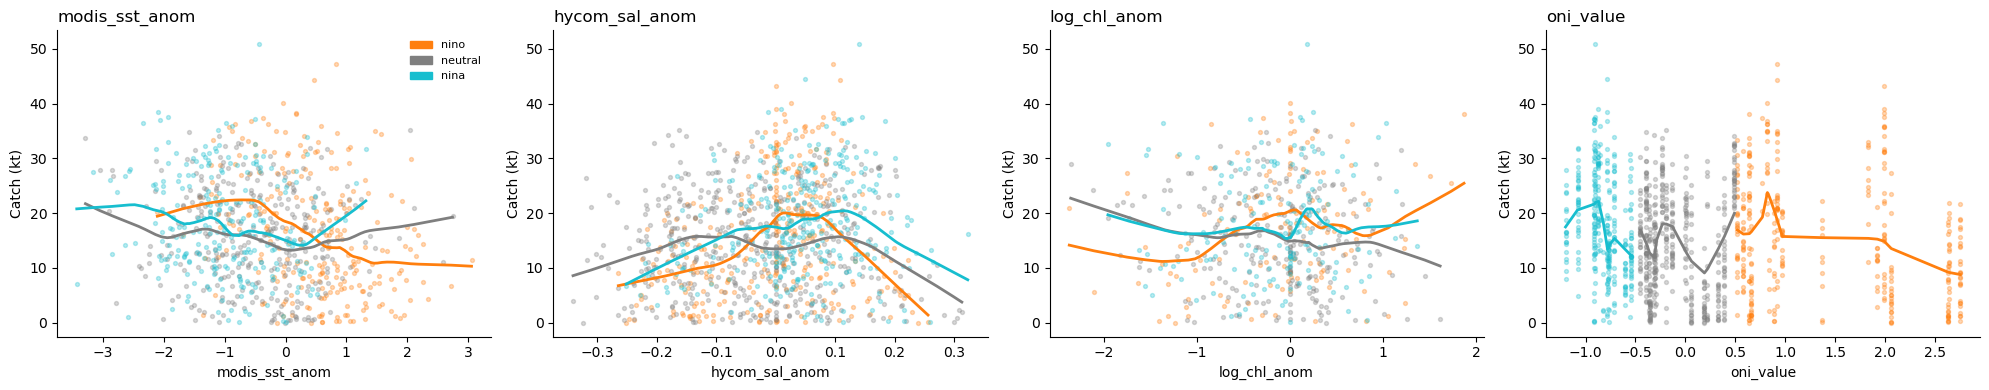

In [8]:
PHASE_COLORS = {'nino': plt.cm.tab10.colors[1],
                'neutral': plt.cm.tab10.colors[7],
                'nina': plt.cm.tab10.colors[9]}

plot_preds = ['modis_sst_anom', 'hycom_sal_anom', 'log_chl_anom', 'oni_value']

fig, axes = plt.subplots(1, len(plot_preds), figsize=(5*len(plot_preds), 4))
for ax, pred in zip(axes, plot_preds):
    for phase, col in PHASE_COLORS.items():
        sub = df[df['enso_phase']==phase][['total_catch_tm', pred]].dropna()
        if len(sub) < 5:
            continue
        ax.scatter(sub[pred], sub['total_catch_tm']/1e3, s=8, alpha=0.3, color=col, label=phase)
        if len(sub) > 10:
            sm = lowess(sub['total_catch_tm'].values/1e3, sub[pred].values, frac=0.4)
            ax.plot(sm[:,0], sm[:,1], color=col, lw=2)
    ax.set_xlabel(pred)
    ax.set_ylabel('Catch (kt)')
    ax.set_title(pred, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, label=ph) for ph, c in PHASE_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(PLOTS / 'step2_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 3 - Weekly aggregation

In [9]:
iso = df['date'].dt.isocalendar()
df['iso_year'] = iso['year'].astype(int)
df['iso_week'] = iso['week'].astype(int)
df['year_week'] = df['iso_year'].astype(str) + '-W' + df['iso_week'].astype(str).str.zfill(2)

df = df.sort_values('date')
df['season_date'] = df.groupby('season')['date'].transform('min')
df['week_of_season'] = ((df['date'] - df['season_date']).dt.days // 7 + 1).astype(int)

wagg = dict(
    weekly_catch_tm         =('total_catch_tm',        'sum'),
    weekly_sst_anom         =('modis_sst_anom',         'mean'),
    weekly_log_chl_anom     =('log_chl_anom',            'mean'),
    weekly_sal_anom         =('hycom_sal_anom',           'mean'),
    weekly_sal_anom_ref35   =('hycom_sal_anom_ref35',     'mean'),
    weekly_temp_anom        =('hycom_temp_anom',          'mean'),
    oni_value               =('oni_value',               'mean'),
    enso_phase              =('enso_phase', lambda x: x.mode()[0] if len(x)>0 else 'neutral'),
    season                  =('season',                  'first'),
    week_of_season          =('week_of_season',          'first'),
)
wdf = df.groupby('year_week').agg(**wagg).reset_index()
wdf = wdf[wdf['weekly_catch_tm'] > 0].copy()

wdf['weekly_sst_anom_pct'] = wdf['weekly_sst_anom'].rank(pct=True) * 100
wdf['log_weekly_catch'] = np.log(wdf['weekly_catch_tm'])

print(f"Weekly panel: {len(wdf):,} rows")
print(wdf[['weekly_catch_tm','weekly_sst_anom','weekly_log_chl_anom','weekly_sal_anom','oni_value']].describe().round(3))


Weekly panel: 184 rows
       weekly_catch_tm  weekly_sst_anom  weekly_log_chl_anom  weekly_sal_anom  \
count          184.000          182.000              173.000          184.000   
mean         94889.318           -0.310               -0.155           -0.006   
std          59183.278            1.000                0.470            0.110   
min            305.000           -3.161               -1.605           -0.310   
25%          53595.000           -1.029               -0.407           -0.077   
50%          90288.000           -0.329               -0.151            0.005   
75%         145086.750            0.422                0.065            0.064   
max         242368.954            2.582                1.732            0.219   

       oni_value  
count    184.000  
mean       0.176  
std        0.998  
min       -1.200  
25%       -0.540  
50%       -0.130  
75%        0.643  
max        2.750  


In [10]:
WPREDS = ['weekly_sst_anom','weekly_temp_anom','weekly_log_chl_anom',
         'weekly_sal_anom','weekly_sal_anom_ref35','oni_value']

def spearman_weekly(data, preds, label=''):
    rows = []
    for p in preds:
        sub = data[['weekly_catch_tm',p]].dropna()
        if len(sub) < 10:
            continue
        rho, pv = spearmanr(sub['weekly_catch_tm'], sub[p])
        rows.append({'predictor':p,'rho':round(rho,3),'p-value':round(pv,4),'N':len(sub)})
    tbl = pd.DataFrame(rows).set_index('predictor')
    if label:
        print(f"\n=== {label} ===")
        print(tbl.to_string())
    return tbl

w_pooled = spearman_weekly(wdf, WPREDS, 'Pooled (weekly)')
w_phase = {}
for phase in ['nino','neutral','nina']:
    w_phase[phase] = spearman_weekly(wdf[wdf['enso_phase']==phase], WPREDS, f'ENSO phase: {phase}')

shared = ['modis_sst_anom→weekly_sst_anom','hycom_sal_anom→weekly_sal_anom',
          'log_chl_anom→weekly_log_chl_anom']
print("\n=== Daily vs Weekly ρ (pooled) ===")
print(f"{'predictor':<35} {'rho_daily':>10} {'rho_weekly':>11}")
pairs_map = [
    ('modis_sst_anom',       'weekly_sst_anom'),
    ('hycom_sal_anom',       'weekly_sal_anom'),
    ('hycom_sal_anom_ref35', 'weekly_sal_anom_ref35'),
    ('log_chl_anom',         'weekly_log_chl_anom'),
    ('hycom_temp_anom',      'weekly_temp_anom'),
    ('oni_value',            'oni_value'),
]
for d_pred, w_pred in pairs_map:
    rd = pooled['rho'].get(d_pred, float('nan'))
    rw = w_pooled['rho'].get(w_pred, float('nan'))
    print(f"{d_pred:<35} {rd:>10.3f} {rw:>11.3f}")



=== Pooled (weekly) ===
                         rho  p-value    N
predictor                                 
weekly_sst_anom       -0.287   0.0001  182
weekly_temp_anom      -0.112   0.1298  184
weekly_log_chl_anom   -0.053   0.4854  173
weekly_sal_anom        0.138   0.0616  184
weekly_sal_anom_ref35  0.369   0.0000  184
oni_value             -0.235   0.0013  184

=== ENSO phase: nino ===
                         rho  p-value   N
predictor                                
weekly_sst_anom       -0.359   0.0057  58
weekly_temp_anom      -0.047   0.7242  58
weekly_log_chl_anom    0.145   0.2954  54
weekly_sal_anom        0.213   0.1078  58
weekly_sal_anom_ref35  0.386   0.0027  58
oni_value             -0.242   0.0670  58

=== ENSO phase: neutral ===
                         rho  p-value   N
predictor                                
weekly_sst_anom       -0.231   0.0473  74
weekly_temp_anom       0.070   0.5477  76
weekly_log_chl_anom   -0.246   0.0402  70
weekly_sal_anom       -0.016  

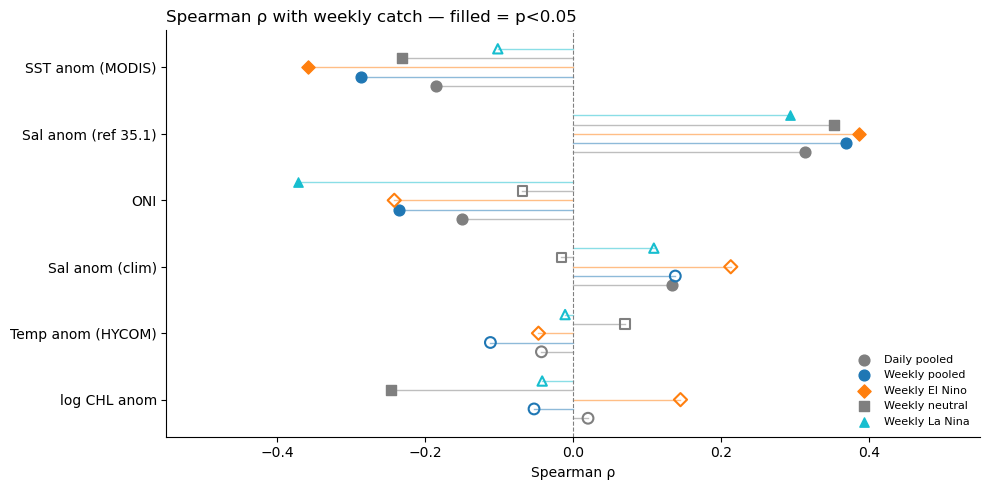

In [11]:
TAB = plt.cm.tab10.colors

daily_rho = {
    'SST anom (MODIS)':   pooled['rho'].get('modis_sst_anom', np.nan),
    'Temp anom (HYCOM)':  pooled['rho'].get('hycom_temp_anom', np.nan),
    'log CHL anom':       pooled['rho'].get('log_chl_anom', np.nan),
    'Sal anom (clim)':    pooled['rho'].get('hycom_sal_anom', np.nan),
    'Sal anom (ref 35.1)':pooled['rho'].get('hycom_sal_anom_ref35', np.nan),
    'ONI':                pooled['rho'].get('oni_value', np.nan),
}

weekly_rho   = {
    'SST anom (MODIS)':    w_pooled['rho'].get('weekly_sst_anom', np.nan),
    'Temp anom (HYCOM)':   w_pooled['rho'].get('weekly_temp_anom', np.nan),
    'log CHL anom':        w_pooled['rho'].get('weekly_log_chl_anom', np.nan),
    'Sal anom (clim)':     w_pooled['rho'].get('weekly_sal_anom', np.nan),
    'Sal anom (ref 35.1)': w_pooled['rho'].get('weekly_sal_anom_ref35', np.nan),
    'ONI':                 w_pooled['rho'].get('oni_value', np.nan),
}

phase_rho = {}
phase_pval = {}
for phase in ['nino','neutral','nina']:
    t = w_phase[phase]
    phase_rho[phase] = {
        'SST anom (MODIS)':    t['rho'].get('weekly_sst_anom', np.nan),
        'Temp anom (HYCOM)':   t['rho'].get('weekly_temp_anom', np.nan),
        'log CHL anom':        t['rho'].get('weekly_log_chl_anom', np.nan),
        'Sal anom (clim)':     t['rho'].get('weekly_sal_anom', np.nan),
        'Sal anom (ref 35.1)': t['rho'].get('weekly_sal_anom_ref35', np.nan),
        'ONI':                 t['rho'].get('oni_value', np.nan),
    }
    phase_pval[phase] = {
        'SST anom (MODIS)':    t['p-value'].get('weekly_sst_anom', 1),
        'Temp anom (HYCOM)':   t['p-value'].get('weekly_temp_anom', 1),
        'log CHL anom':        t['p-value'].get('weekly_log_chl_anom', 1),
        'Sal anom (clim)':     t['p-value'].get('weekly_sal_anom', 1),
        'Sal anom (ref 35.1)': t['p-value'].get('weekly_sal_anom_ref35', 1),
        'ONI':                 t['p-value'].get('oni_value', 1),
    }
daily_pval = {
    'SST anom (MODIS)':    pooled['p-value'].get('modis_sst_anom', 1),
    'Temp anom (HYCOM)':   pooled['p-value'].get('hycom_temp_anom', 1),
    'log CHL anom':        pooled['p-value'].get('log_chl_anom', 1),
    'Sal anom (clim)':     pooled['p-value'].get('hycom_sal_anom', 1),
    'Sal anom (ref 35.1)': pooled['p-value'].get('hycom_sal_anom_ref35', 1),
    'ONI':                 pooled['p-value'].get('oni_value', 1),
}
weekly_pval = {
    'SST anom (MODIS)':    w_pooled['p-value'].get('weekly_sst_anom', 1),
    'Temp anom (HYCOM)':   w_pooled['p-value'].get('weekly_temp_anom', 1),
    'log CHL anom':        w_pooled['p-value'].get('weekly_log_chl_anom', 1),
    'Sal anom (clim)':     w_pooled['p-value'].get('weekly_sal_anom', 1),
    'Sal anom (ref 35.1)': w_pooled['p-value'].get('weekly_sal_anom_ref35', 1),
    'ONI':                 w_pooled['p-value'].get('oni_value', 1),
}

predictors = [
    'log CHL anom',
    'Temp anom (HYCOM)',
    'Sal anom (clim)',
    'ONI',
    'Sal anom (ref 35.1)',
    'SST anom (MODIS)',
]
y = np.arange(len(predictors))

SERIES = [
    ('Daily pooled',    daily_rho,              daily_pval,             TAB[7], 'o',  60),
    ('Weekly pooled',   weekly_rho,             weekly_pval,            TAB[0], 'o',  60),
    ('Weekly El Nino',  phase_rho['nino'],      phase_pval['nino'],     TAB[1], 'D',  45),
    ('Weekly neutral',  phase_rho['neutral'],   phase_pval['neutral'],  TAB[7], 's',  45),
    ('Weekly La Nina',  phase_rho['nina'],      phase_pval['nina'],     TAB[9], '^',  45),
]

n   = len(SERIES)
gap = 0.14
offsets = np.linspace(-(n-1)*gap/2, (n-1)*gap/2, n)

fig, ax = plt.subplots(figsize=(10, 5))

for (label, rhos, pvals, col, mk, ms), offset in zip(SERIES, offsets):
    vals = [rhos[p] for p in predictors]
    pvs  = [pvals[p] for p in predictors]
    ypos = y + offset

    for yi, v in zip(ypos, vals):
        ax.plot([0, v], [yi, yi], color=col, lw=1, alpha=0.5)

    for yi, v, pv in zip(ypos, vals, pvs):
        if pv < 0.05:
            ax.scatter(v, yi, color=col, marker=mk, s=ms, zorder=5, label=None)
        else:
            ax.scatter(v, yi, color=col, marker=mk, s=ms, zorder=5,
                       facecolors='none', linewidths=1.5, label=None)

    ax.scatter([], [], color=col, marker=mk, s=ms, label=label)

ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_yticks(y)
ax.set_yticklabels(predictors)
ax.set_xlabel('Spearman ρ')
ax.set_title('Spearman ρ with weekly catch — filled = p<0.05', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.set_xlim(-0.55, 0.55)

plt.tight_layout()
plt.savefig(PLOTS / 'step2_rho_comparison.png', dpi=120)
plt.show()


## Step 4 - Baseline OLS (daily, no interactions)
`log(catch) ~ modis_sst_anom + log_chl_anom + hycom_sal_anom`  
HYCOM robustness check alongside.

=== Step 4 — Baseline OLS ===
                            model  adj_R2    N    coef      se       p
modis_sst_anom      MODIS primary  0.0309  550 -0.1297  0.0420  0.0021
log_chl_anom        MODIS primary  0.0309  550  0.0006  0.0617  0.9929
hycom_sal_anom      MODIS primary  0.0309  550  0.8608  0.3694  0.0202
hycom_temp_anom  HYCOM robustness  0.0151  557 -0.0336  0.0593  0.5712
log_chl_anom     HYCOM robustness  0.0151  557  0.0005  0.0615  0.9939
hycom_sal_anom   HYCOM robustness  0.0151  557  1.2003  0.3560  0.0008


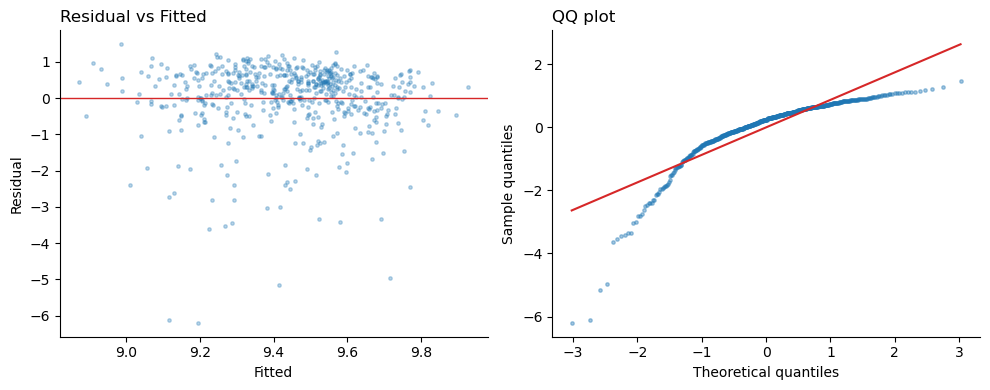

In [12]:
df_pos = df[df['total_catch_tm'] > 0].copy()

def run_ols(formula, data, label):
    keep = [v.strip() for v in formula.split('~')[1]
            .replace('I(','').replace('**2)','').replace('*','+').split('+')]
    keep = [v for v in keep if v in data.columns]
    sub  = data.dropna(subset=keep+['log_catch'])
    m    = smf.ols(formula, data=sub).fit()
    coef = m.params.drop('Intercept', errors='ignore')
    se   = m.bse.drop('Intercept', errors='ignore')
    pv   = m.pvalues.drop('Intercept', errors='ignore')
    tbl  = pd.DataFrame({'coef':coef.round(4),'se':se.round(4),'p':pv.round(4)})
    tbl.insert(0,'model',label)
    tbl.insert(1,'adj_R2',round(m.rsquared_adj,4))
    tbl.insert(2,'N',int(m.nobs))
    return m, tbl

f4a = 'log_catch ~ modis_sst_anom + log_chl_anom + hycom_sal_anom'
f4b = 'log_catch ~ hycom_temp_anom + log_chl_anom + hycom_sal_anom'

m4a, t4a = run_ols(f4a, df_pos, 'MODIS primary')
m4b, t4b = run_ols(f4b, df_pos, 'HYCOM robustness')
tbl4 = pd.concat([t4a, t4b])
print("=== Step 4 — Baseline OLS ===")
print(tbl4.to_string())

TAB = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
fitted = m4a.fittedvalues; resid = m4a.resid
ax.scatter(fitted, resid, s=6, alpha=0.3, color=TAB[0])
ax.axhline(0, color=TAB[3], lw=1)
ax.set_xlabel('Fitted'); ax.set_ylabel('Residual')
ax.set_title('Residual vs Fitted', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

from scipy.stats import probplot
ax = axes[1]
(osm, osr), (slope, intercept, r) = probplot(resid)
ax.scatter(osm, osr, s=6, alpha=0.4, color=TAB[0])
ax.plot(osm, slope*np.array(osm)+intercept, color=TAB[3], lw=1.5)
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
ax.set_title('QQ plot', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS / 'step4_diag.png', dpi=120)
plt.show()


## Step 5 - OLS with quadratic SST (daily)
`log(catch) ~ modis_sst_anom + modis_sst_anom² + log_chl_anom + hycom_sal_anom`

=== Step 5 — Quadratic SST ===
                                model  adj_R2    N    coef      se       p
modis_sst_anom          Quadratic SST  0.0302  550 -0.1158  0.0455  0.0113
I(modis_sst_anom ** 2)  Quadratic SST  0.0302  550  0.0226  0.0286  0.4291
log_chl_anom            Quadratic SST  0.0302  550  0.0043  0.0619  0.9445
hycom_sal_anom          Quadratic SST  0.0302  550  0.8755  0.3700  0.0183
adj R²: step4=0.0309  step5=0.0302  Δ=-0.0007


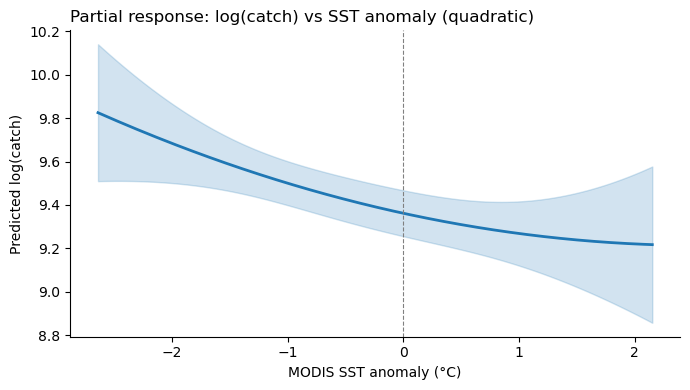

In [13]:
f5 = 'log_catch ~ modis_sst_anom + I(modis_sst_anom**2) + log_chl_anom + hycom_sal_anom'
m5, t5 = run_ols(f5, df_pos, 'Quadratic SST')
print("=== Step 5 — Quadratic SST ===")
print(t5.to_string())
print(f"adj R²: step4={m4a.rsquared_adj:.4f}  step5={m5.rsquared_adj:.4f}  Δ={m5.rsquared_adj-m4a.rsquared_adj:+.4f}")

TAB = plt.cm.tab10.colors

sub5 = df_pos.dropna(subset=['log_catch','modis_sst_anom','log_chl_anom','hycom_sal_anom'])
sst_grid = np.linspace(sub5['modis_sst_anom'].quantile(0.01),
                       sub5['modis_sst_anom'].quantile(0.99), 200)
pred_data = pd.DataFrame({
    'modis_sst_anom': sst_grid,
    'log_chl_anom':   sub5['log_chl_anom'].mean(),
    'hycom_sal_anom': sub5['hycom_sal_anom'].mean(),
})
pred = m5.get_prediction(pred_data)
pmean = pred.predicted_mean
ci    = pred.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sst_grid, pmean, color=TAB[0], lw=2)
ax.fill_between(sst_grid, ci[:,0], ci[:,1], alpha=0.2, color=TAB[0])
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('MODIS SST anomaly (°C)')
ax.set_ylabel('Predicted log(catch)')
ax.set_title('Partial response: log(catch) vs SST anomaly (quadratic)', loc='left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS / 'step5_partial.png', dpi=120)
plt.show()


## Step 6 - OLS with interactions (daily)
Test whether the SST effect on catch depends on chlorophyll and salinity conditions.

In [14]:
f6 = ('log_catch ~ modis_sst_anom + I(modis_sst_anom**2) + log_chl_anom + hycom_sal_anom'
     ' + modis_sst_anom:log_chl_anom + modis_sst_anom:hycom_sal_anom')
m6, t6 = run_ols(f6, df_pos, 'Interactions')
print("=== Step 6 — OLS with interactions ===")
print(t6.to_string())
print(f"adj R²: step5={m5.rsquared_adj:.4f}  step6={m6.rsquared_adj:.4f}  Δ={m6.rsquared_adj-m5.rsquared_adj:+.4f}")

sig_int_chl = m6.pvalues.get('modis_sst_anom:log_chl_anom', 1.0)
sig_int_sal = m6.pvalues.get('modis_sst_anom:hycom_sal_anom', 1.0)
print(f"\nInteraction p-values: SST×CHL={sig_int_chl:.4f}  SST×SAL={sig_int_sal:.4f}")

TAB = plt.cm.tab10.colors

if sig_int_chl < 0.1:
    sub6 = df_pos.dropna(subset=['log_catch','modis_sst_anom','log_chl_anom','hycom_sal_anom'])
    chl_lo, chl_med, chl_hi = sub6['log_chl_anom'].quantile([0.2, 0.5, 0.8])
    sal_med = sub6['hycom_sal_anom'].mean()

    fig, ax = plt.subplots(figsize=(7, 4))
    for chl_val, lbl, col in [(chl_lo,'low CHL',TAB[2]),(chl_med,'med CHL',TAB[1]),(chl_hi,'high CHL',TAB[0])]:
        pd_grid = pd.DataFrame({
            'modis_sst_anom': sst_grid,
            'log_chl_anom':   chl_val,
            'hycom_sal_anom': sal_med,
        })
        pr = m6.get_prediction(pd_grid)
        ax.plot(sst_grid, pr.predicted_mean, lw=2, color=col, label=lbl)
    ax.set_xlabel('MODIS SST anomaly (°C)')
    ax.set_ylabel('Predicted log(catch)')
    ax.set_title('Interaction surface: log(catch) ~ SST × CHL anomaly', loc='left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(PLOTS / 'step6_interaction.png', dpi=120)
    plt.show()
else:
    print("SST×CHL interaction not significant at α=0.1 — skipping surface plot.")


=== Step 6 — OLS with interactions ===
                                      model  adj_R2    N    coef      se       p
modis_sst_anom                 Interactions  0.0328  550 -0.0799  0.0499  0.1097
I(modis_sst_anom ** 2)         Interactions  0.0328  550  0.0387  0.0300  0.1967
log_chl_anom                   Interactions  0.0328  550  0.0105  0.0630  0.8682
hycom_sal_anom                 Interactions  0.0328  550  1.1349  0.4005  0.0048
modis_sst_anom:log_chl_anom    Interactions  0.0328  550  0.0476  0.0631  0.4513
modis_sst_anom:hycom_sal_anom  Interactions  0.0328  550  0.6326  0.3715  0.0892
adj R²: step5=0.0302  step6=0.0328  Δ=+0.0026

Interaction p-values: SST×CHL=0.4513  SST×SAL=0.0892
SST×CHL interaction not significant at α=0.1 — skipping surface plot.


## Step 7 - ENSO as covariate and stratifier (daily)
7a: ONI as additive covariate. 7b: Separate regressions per ENSO phase. Both with season fixed effects.

In [15]:
f7a = ('log_catch ~ modis_sst_anom + I(modis_sst_anom**2) + log_chl_anom + hycom_sal_anom'
       ' + modis_sst_anom:log_chl_anom + modis_sst_anom:hycom_sal_anom'
       ' + oni_value + C(season)')
m7a, t7a = run_ols(f7a, df_pos.dropna(subset=['oni_value']), 'Step7a ONI+season FE')
env_vars = ['modis_sst_anom','I(modis_sst_anom ** 2)','log_chl_anom','hycom_sal_anom',
            'modis_sst_anom:log_chl_anom','modis_sst_anom:hycom_sal_anom','oni_value']
print("=== Step 7a — ONI as additive covariate + season FE ===")
print(t7a[t7a.index.isin(env_vars)].to_string())
print(f"adj R²={m7a.rsquared_adj:.4f}  N={int(m7a.nobs)}")


=== Step 7a — ONI as additive covariate + season FE ===
                                              model  adj_R2    N    coef      se       p
modis_sst_anom                 Step7a ONI+season FE  0.1122  550  0.0146  0.0698  0.8340
I(modis_sst_anom ** 2)         Step7a ONI+season FE  0.1122  550  0.0493  0.0331  0.1368
log_chl_anom                   Step7a ONI+season FE  0.1122  550  0.0356  0.0621  0.5663
hycom_sal_anom                 Step7a ONI+season FE  0.1122  550 -0.4600  0.5928  0.4381
modis_sst_anom:log_chl_anom    Step7a ONI+season FE  0.1122  550  0.0365  0.0614  0.5523
modis_sst_anom:hycom_sal_anom  Step7a ONI+season FE  0.1122  550  0.2443  0.4347  0.5743
oni_value                      Step7a ONI+season FE  0.1122  550  0.1827  0.3385  0.5895
adj R²=0.1122  N=550


In [16]:
f7b = ('log_catch ~ modis_sst_anom + I(modis_sst_anom**2) + log_chl_anom + hycom_sal_anom'
       ' + modis_sst_anom:log_chl_anom + modis_sst_anom:hycom_sal_anom + C(season)')
phase_results = {}
for phase in ['nino','neutral','nina']:
    sub = df_pos[df_pos['enso_phase']==phase].dropna(
        subset=['log_catch','modis_sst_anom','log_chl_anom','hycom_sal_anom'])
    if len(sub) < 30:
        print(f"  {phase}: too few obs ({len(sub)}) — skipped")
        continue
    m, t = run_ols(f7b, sub, f'Step7b {phase}')
    phase_results[phase] = (m, t)
    print(f"\n=== Step 7b — {phase.upper()} (N={int(m.nobs)}, adj R²={m.rsquared_adj:.4f}) ===")
    env_coefs = t[t.index.isin(['modis_sst_anom','I(modis_sst_anom ** 2)',
                                 'log_chl_anom','hycom_sal_anom',
                                 'modis_sst_anom:log_chl_anom','modis_sst_anom:hycom_sal_anom'])]
    print(env_coefs.to_string())

print("\n=== Coefficient shift across ENSO phases (SST linear term) ===")
for phase, (m, _) in phase_results.items():
    coef = m.params.get('modis_sst_anom', float('nan'))
    pv   = m.pvalues.get('modis_sst_anom', float('nan'))
    print(f"  {phase:8s}: β_sst={coef:+.4f}  p={pv:.4f}")



=== Step 7b — NINO (N=142, adj R²=0.1748) ===
                                     model  adj_R2    N    coef      se       p
modis_sst_anom                 Step7b nino  0.1748  142 -0.1895  0.1836  0.3040
I(modis_sst_anom ** 2)         Step7b nino  0.1748  142  0.0622  0.1071  0.5626
log_chl_anom                   Step7b nino  0.1748  142  0.2558  0.1500  0.0905
hycom_sal_anom                 Step7b nino  0.1748  142  3.4227  1.2989  0.0094
modis_sst_anom:log_chl_anom    Step7b nino  0.1748  142 -0.1475  0.1628  0.3669
modis_sst_anom:hycom_sal_anom  Step7b nino  0.1748  142 -0.4723  1.2331  0.7024

=== Step 7b — NEUTRAL (N=245, adj R²=0.2090) ===
                                        model  adj_R2    N    coef      se       p
modis_sst_anom                 Step7b neutral   0.209  245  0.0094  0.1002  0.9257
I(modis_sst_anom ** 2)         Step7b neutral   0.209  245  0.0573  0.0501  0.2539
log_chl_anom                   Step7b neutral   0.209  245 -0.0966  0.0991  0.3305
hycom_sal_a

In [17]:
r2_summary = pd.DataFrame([
    {'Step':'Step4 baseline',       'adj_R2': m4a.rsquared_adj, 'N': int(m4a.nobs)},
    {'Step':'Step5 quad SST',       'adj_R2': m5.rsquared_adj,  'N': int(m5.nobs)},
    {'Step':'Step6 interactions',   'adj_R2': m6.rsquared_adj,  'N': int(m6.nobs)},
    {'Step':'Step7a ONI+season FE', 'adj_R2': m7a.rsquared_adj, 'N': int(m7a.nobs)},
]).set_index('Step')
print("\n=== adj R² progression Steps 4-7 (daily) ===")
print(r2_summary.round(4).to_string())



=== adj R² progression Steps 4-7 (daily) ===
                      adj_R2    N
Step                             
Step4 baseline        0.0309  550
Step5 quad SST        0.0302  550
Step6 interactions    0.0328  550
Step7a ONI+season FE  0.1122  550


## Step 8 - Repeat Steps 4-7 on weekly data
Same model sequence on the weekly dataset. Summary table comparing adj R² daily vs weekly.

In [18]:
wpos = wdf[wdf['weekly_catch_tm'] > 0].dropna(
    subset=['log_weekly_catch','weekly_sst_anom','weekly_log_chl_anom','weekly_sal_anom']).copy()

def run_ols_w(formula, data, label):
    keep = [v.strip() for v in formula.split('~')[1]
            .replace('I(','').replace('**2)','').replace('*','+').split('+')]
    keep = [v for v in keep if v in data.columns]
    sub  = data.dropna(subset=keep+['log_weekly_catch'])
    m    = smf.ols(formula, data=sub).fit()
    coef = m.params.drop('Intercept', errors='ignore')
    se   = m.bse.drop('Intercept', errors='ignore')
    pv   = m.pvalues.drop('Intercept', errors='ignore')
    tbl  = pd.DataFrame({'coef':coef.round(4),'se':se.round(4),'p':pv.round(4)})
    tbl.insert(0,'model',label)
    tbl.insert(1,'adj_R2',round(m.rsquared_adj,4))
    tbl.insert(2,'N',int(m.nobs))
    return m, tbl

fw4  = 'log_weekly_catch ~ weekly_sst_anom + weekly_log_chl_anom + weekly_sal_anom'
fw5  = 'log_weekly_catch ~ weekly_sst_anom + I(weekly_sst_anom**2) + weekly_log_chl_anom + weekly_sal_anom'
fw6  = ('log_weekly_catch ~ weekly_sst_anom + I(weekly_sst_anom**2) + weekly_log_chl_anom + weekly_sal_anom'
        ' + weekly_sst_anom:weekly_log_chl_anom + weekly_sst_anom:weekly_sal_anom')
fw7a = (fw6.replace('log_weekly_catch ~',
        'log_weekly_catch ~').rstrip() + ' + oni_value + C(season)')

mw4, tw4 = run_ols_w(fw4,  wpos, 'W-Step4 baseline')
mw5, tw5 = run_ols_w(fw5,  wpos, 'W-Step5 quad')
mw6, tw6 = run_ols_w(fw6,  wpos, 'W-Step6 interactions')
mw7a,tw7a= run_ols_w(fw7a, wpos.dropna(subset=['oni_value']), 'W-Step7a ONI+season FE')

wphase_results = {}
fw7b = fw6 + ' + C(season)'
for phase in ['nino','neutral','nina']:
    sub = wpos[wpos['enso_phase']==phase]
    if len(sub) < 20:
        print(f"Weekly {phase}: too few obs ({len(sub)}) — skipped")
        continue
    m, t = run_ols_w(fw7b, sub, f'W-Step7b {phase}')
    wphase_results[phase] = (m, t)
    print(f"W-Step7b {phase}: adj R²={m.rsquared_adj:.4f}  N={int(m.nobs)}")

comp_r2 = pd.DataFrame([
    {'Step':'Step4 baseline',    'adj_R2_daily':m4a.rsquared_adj,  'adj_R2_weekly':mw4.rsquared_adj},
    {'Step':'Step5 quad SST',    'adj_R2_daily':m5.rsquared_adj,   'adj_R2_weekly':mw5.rsquared_adj},
    {'Step':'Step6 interactions','adj_R2_daily':m6.rsquared_adj,   'adj_R2_weekly':mw6.rsquared_adj},
    {'Step':'Step7a ONI+FE',     'adj_R2_daily':m7a.rsquared_adj,  'adj_R2_weekly':mw7a.rsquared_adj},
]).set_index('Step')
print("\n=== adj R² comparison: daily vs weekly ===")
print(comp_r2.round(4).to_string())


W-Step7b nino: adj R²=-0.0152  N=54
W-Step7b neutral: adj R²=0.2074  N=70
W-Step7b nina: adj R²=0.4569  N=49

=== adj R² comparison: daily vs weekly ===
                    adj_R2_daily  adj_R2_weekly
Step                                           
Step4 baseline            0.0309         0.0363
Step5 quad SST            0.0302         0.0412
Step6 interactions        0.0328         0.0384
Step7a ONI+FE             0.1122         0.1447


## Step 8a - Vessel location density by season

2D density map of cala locations pooled across all years, split by primera and segunda temporada. Shared color scale so densities are directly comparable between seasons.

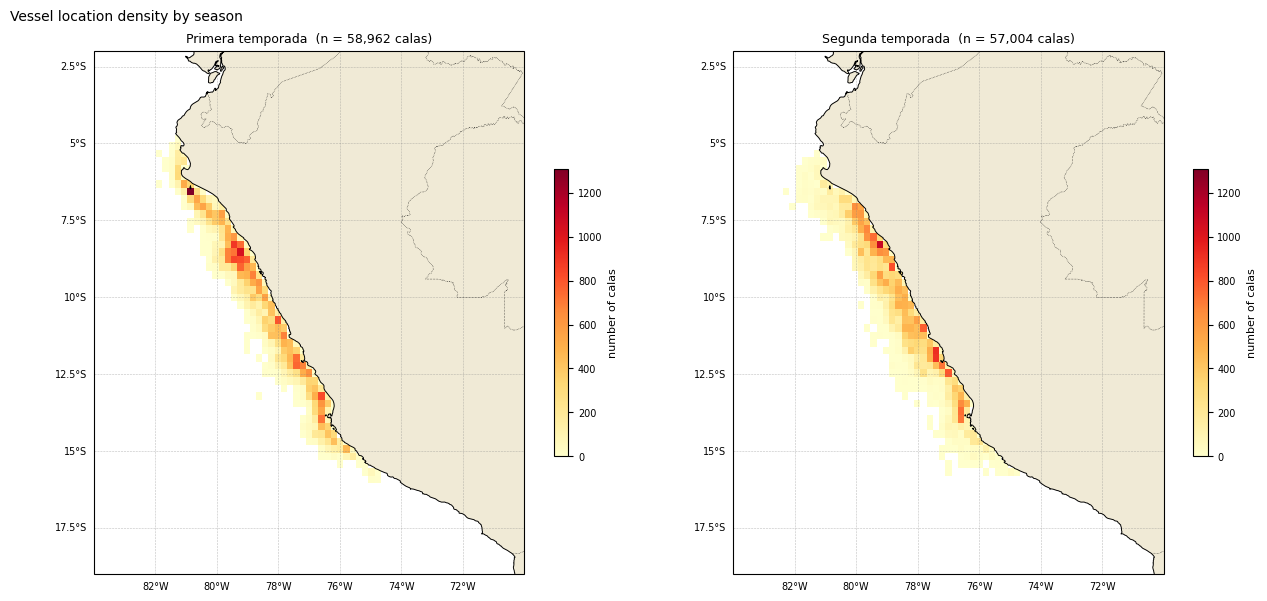

Saved -> /home/jupyter-daniela/peru_catch_modeling/outputs/step8a_vessel_density_by_season.png


In [19]:
df_raw['season_type'] = df_raw['season'].str.extract(r'^(1ra|2da)')

LON_EDGES = np.linspace(-84, -70, 70)
LAT_EDGES = np.linspace(-19, -2, 70)
LON_C = (LON_EDGES[:-1] + LON_EDGES[1:]) / 2
LAT_C = (LAT_EDGES[:-1] + LAT_EDGES[1:]) / 2

EXT_ZOOM = [-84, -70, -19, -2]

fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                         subplot_kw={'projection': PROJ})

labels = {'1ra': 'Primera temporada', '2da': 'Segunda temporada'}

grids = {}
for stype in ['1ra', '2da']:
    sub = df_raw[df_raw['season_type'] == stype].dropna(subset=['lat', 'lon'])
    H, _, _ = np.histogram2d(sub['lon'], sub['lat'],
                             bins=[LON_EDGES, LAT_EDGES])
    grids[stype] = H.T

vmax = max(g.max() for g in grids.values())

for ax, stype in zip(axes, ['1ra', '2da']):
    H_masked = np.ma.masked_where(grids[stype] == 0, grids[stype])

    ax.set_extent(EXT_ZOOM, crs=PROJ)
    ax.add_feature(cfeature.LAND,      facecolor='#f0ead6', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7,       zorder=3)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=':', zorder=3)
    add_gridlines(ax)

    mesh = ax.pcolormesh(LON_C, LAT_C, H_masked,
                         transform=PROJ, cmap='YlOrRd',
                         vmin=0, vmax=vmax, zorder=1)

    cb = plt.colorbar(mesh, ax=ax, shrink=0.55, pad=0.05)
    cb.set_label('number of calas', size=8)
    cb.ax.tick_params(labelsize=7)

    n_total = int(df_raw[df_raw['season_type'] == stype].dropna(subset=['lat', 'lon']).shape[0])
    ax.set_title(f"{labels[stype]}  (n = {n_total:,} calas)", fontsize=9)

fig.suptitle('Vessel location density by season', fontsize=10, x=0.01, ha='left')
plt.tight_layout()
plt.savefig(PLOTS / 'step8a_vessel_density_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {PLOTS / 'step8a_vessel_density_by_season.png'}")

## Step 8b - Tobit regression: catch decay under environmental extremes

**Why Tobit?**  
Weeks where fishing was suppressed (zero catch) are dropped from OLS - but those are precisely the worst environmental conditions. Tobit treats them as *left-censored*: the latent `log(catch)` would have been observed if fishing had occurred.

**Two univariate models** on the full seasonal panel:
- `log(weekly_catch) ~ SST_anom`  
- `log(weekly_catch) ~ sal_anom_ref35`

**Interpretation**  
- Censoring point `L = log(1 tm)` - any week with catch < 1 tm is left-censored  
- β is a **semi-elasticity**: a 1-unit anomaly → β × 100 % change in catch  
- `exp(β × Δx) − 1` gives the predicted % decay at any anomaly Δx

In [20]:
from scipy.optimize import minimize, approx_fprime
from scipy.stats import norm as sp_norm

FEAT = Path('/home/jupyter-daniela/suyana/peru_production/features/')
L_CENS = 0.0

def iso_week_label(d):
    iso = d.isocalendar()
    return f"{iso.year}-W{iso.week:02d}"

obs_cols = ['year_week', 'weekly_catch_tm', 'weekly_sst_anom',
            'weekly_sal_anom_ref35', 'season', 'enso_phase', 'oni_value']
obs = wdf[wdf['weekly_catch_tm'] > 0][obs_cols].copy()
obs['log_weekly_catch'] = np.log(obs['weekly_catch_tm'])

df_tmp = df[['date','season']].copy()
df_tmp['date'] = pd.to_datetime(df_tmp['date'])
season_windows = df_tmp.groupby('season')['date'].agg(['min','max'])

all_weeks = []
for season_label, row in season_windows.iterrows():
    d = row['min']
    while d <= row['max']:
        all_weeks.append({'season': season_label,
                          'year_week': iso_week_label(d)})
        d += pd.Timedelta(weeks=1)

full_panel = (pd.DataFrame(all_weeks)
              .drop_duplicates()
              .merge(obs, on=['year_week','season'], how='left'))
full_panel['censored'] = full_panel['weekly_catch_tm'].isna()
full_panel['log_weekly_catch'] = full_panel['log_weekly_catch'].fillna(np.nan)

n_obs  = (~full_panel['censored']).sum()
n_cens = full_panel['censored'].sum()
print(f"Full panel: {len(full_panel)} weeks | observed: {n_obs} | censored: {n_cens}")

def week_dates(yw):
    y, w = int(yw.split('-W')[0]), int(yw.split('-W')[1])
    return (pd.Timestamp.fromisocalendar(y, w, 1),
            pd.Timestamp.fromisocalendar(y, w, 7))

def area_avg_week(yw, nc_tpl, var, subtract=0.0):
    mon, sun = week_dates(yw)
    vals = []
    for d in pd.date_range(mon, sun):
        fpath = FEAT / nc_tpl.format(year=d.year)
        if not fpath.exists():
            continue
        ds = xr.open_dataset(fpath)
        times = pd.to_datetime(ds['time'].values)
        t_idx = int(np.argmin(np.abs(times - d)))
        arr   = ds[var].isel(time=t_idx)
        if 'depth' in arr.dims:
            arr = arr.isel(depth=0)
        vals.append(float(np.nanmean(arr.values)))
        ds.close()
    return (np.nanmean(vals) - subtract) if vals else np.nan

for idx in full_panel[full_panel['censored']].index:
    yw = full_panel.at[idx, 'year_week']
    full_panel.at[idx, 'weekly_sst_anom']      = area_avg_week(
        yw, 'sst_anomaly_daily_{year}.nc', 'sst_anomaly')
    full_panel.at[idx, 'weekly_sal_anom_ref35'] = area_avg_week(
        yw, 'hycom_salinity_daily_{year}.nc', 'salinity', subtract=35.1)

full_panel = full_panel.dropna(subset=['weekly_sst_anom', 'weekly_sal_anom_ref35'])
print(f"After env fill: {len(full_panel)} rows  "
      f"(censored: {full_panel['censored'].sum()})")

def tobit_nll(params, X, y, censored, L=L_CENS):
    beta  = params[:-1]
    sigma = np.exp(params[-1])
    xb    = X @ beta
    ll    = np.zeros(len(y))
    ll[~censored] = sp_norm.logpdf(y[~censored], loc=xb[~censored], scale=sigma)
    ll[ censored] = sp_norm.logcdf(L,            loc=xb[ censored], scale=sigma)
    return -ll.sum()

def fit_tobit(x_col, x_label, data=full_panel):
    sub = data.dropna(subset=[x_col]).copy()
    cens = sub['censored'].values
    y    = sub['log_weekly_catch'].fillna(L_CENS).values
    X    = np.column_stack([np.ones(len(sub)), sub[x_col].values])

    obs_mask = ~cens
    _m = np.linalg.lstsq(X[obs_mask], y[obs_mask], rcond=None)
    b0 = _m[0]
    resid = y[obs_mask] - X[obs_mask] @ b0
    s0    = np.log(resid.std() + 1e-6)
    p0    = np.append(b0, s0)

    res = minimize(tobit_nll, p0, args=(X, y, cens),
                   method='L-BFGS-B', options={'maxiter': 10000, 'ftol': 1e-12})

    beta_hat  = res.x[:-1]
    sigma_hat = np.exp(res.x[-1])

    eps  = 1e-5
    n    = len(res.x)
    nll_fn = lambda p: tobit_nll(p, X, y, cens)
    grad0  = approx_fprime(res.x, nll_fn, eps)
    hess   = np.zeros((n, n))
    for i in range(n):
        x_fwd      = res.x.copy()
        x_fwd[i]  += eps
        grad_fwd   = approx_fprime(x_fwd, nll_fn, eps)
        hess[i]    = (grad_fwd - grad0) / eps
    hess  = (hess + hess.T) / 2
    vcov  = np.linalg.pinv(hess)
    se    = np.sqrt(np.maximum(np.diag(vcov)[:-1], 0))
    z     = beta_hat / (se + 1e-10)
    pval  = 2 * (1 - sp_norm.cdf(np.abs(z)))

    import statsmodels.formula.api as smf_
    _ols = smf_.ols(f'log_weekly_catch ~ {x_col}',
                   data=sub[~cens].dropna(subset=['log_weekly_catch'])).fit()

    pctiles = np.percentile(sub[x_col], [5, 10, 25, 50, 75, 90, 95])
    ref_val  = np.median(sub.loc[~cens, x_col])
    pct_change_tb  = (np.exp(beta_hat[1] * (pctiles - ref_val)) - 1) * 100
    pct_change_ols = (np.exp(_ols.params[x_col] * (pctiles - ref_val)) - 1) * 100

    print(f"\n{'='*60}")
    print(f"  {x_label}")
    print(f"{'='*60}")
    print(f"  Tobit  b = {beta_hat[1]:+.4f}  SE={se[1]:.4f}  z={z[1]:.2f}  p={pval[1]:.4f}")
    print(f"  OLS    b = {_ols.params[x_col]:+.4f}  SE={_ols.bse[x_col]:.4f}  "
          f"t={_ols.tvalues[x_col]:.2f}  p={_ols.pvalues[x_col]:.4f}")
    print(f"  Sigma  = {sigma_hat:.3f} (log-scale)")
    print(f"  OLS adj-R2 = {_ols.rsquared_adj:.4f}  (observed only, N={int(_ols.nobs)})")
    print(f"  Baseline reference = {ref_val:.3f} (median of observed weeks)")
    pct_tbl = pd.DataFrame({
        'percentile': [5, 10, 25, 50, 75, 90, 95],
        'anomaly value': np.round(pctiles, 3),
        'Tobit % Dcatch': np.round(pct_change_tb, 1),
        'OLS % Dcatch':   np.round(pct_change_ols, 1),
    }).set_index('percentile')
    print(pct_tbl.to_string())

    return {
        'x_col': x_col, 'label': x_label,
        'beta_tb': beta_hat[1],  'se_tb':  se[1],  'pval_tb': pval[1],
        'beta_ols': _ols.params[x_col], 'pval_ols': _ols.pvalues[x_col],
        'sigma': sigma_hat, 'sub': sub, 'cens': cens,
        'pctiles': pctiles, 'ref_val': ref_val,
        'pct_change_tb': pct_change_tb, 'pct_change_ols': pct_change_ols,
    }

r_sst = fit_tobit('weekly_sst_anom',      'log(catch) ~ SST anomaly (°C)')
r_sal = fit_tobit('weekly_sal_anom_ref35', 'log(catch) ~ Salinity anomaly vs 35.1 PSU')

Full panel: 183 weeks | observed: 175 | censored: 8


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


...

sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


sh: 1: getfattr: not found
sh: 1: getfattr: not found
sh: 1: getfattr: not found


After env fill: 182 rows  (censored: 8)

  log(catch) ~ SST anomaly (°C)
  Tobit  b = -0.9057  SE=0.1797  z=-5.04  p=0.0000
  OLS    b = -0.1915  SE=0.0755  t=-2.54  p=0.0121
  Sigma  = 2.436 (log-scale)
  OLS adj-R2 = 0.0304  (observed only, N=174)
  Baseline reference = -0.384 (median of observed weeks)
            anomaly value  Tobit % Dcatch  OLS % Dcatch
percentile                                             
5                  -1.805           262.1          31.3
10                 -1.411           153.5          21.7
25                 -1.024            78.5          13.0
50                 -0.321            -5.6          -1.2
75                  0.467           -53.7         -15.0
90                  1.132           -74.7         -25.2
95                  1.389           -79.9         -28.8



  log(catch) ~ Salinity anomaly vs 35.1 PSU
  Tobit  b = +6.2185  SE=1.3950  z=4.46  p=0.0000
  OLS    b = +1.8688  SE=0.5567  t=3.36  p=0.0010
  Sigma  = 2.469 (log-scale)
  OLS adj-R2 = 0.0560  (observed only, N=174)
  Baseline reference = 0.227 (median of observed weeks)
            anomaly value  Tobit % Dcatch  OLS % Dcatch
percentile                                             
5                  -0.002           -75.8         -34.7
10                  0.018           -72.7         -32.3
25                  0.105           -53.1         -20.3
50                  0.223            -1.9          -0.6
75                  0.295            52.9          13.6
90                  0.379           157.4          32.9
95                  0.399           193.1          38.1


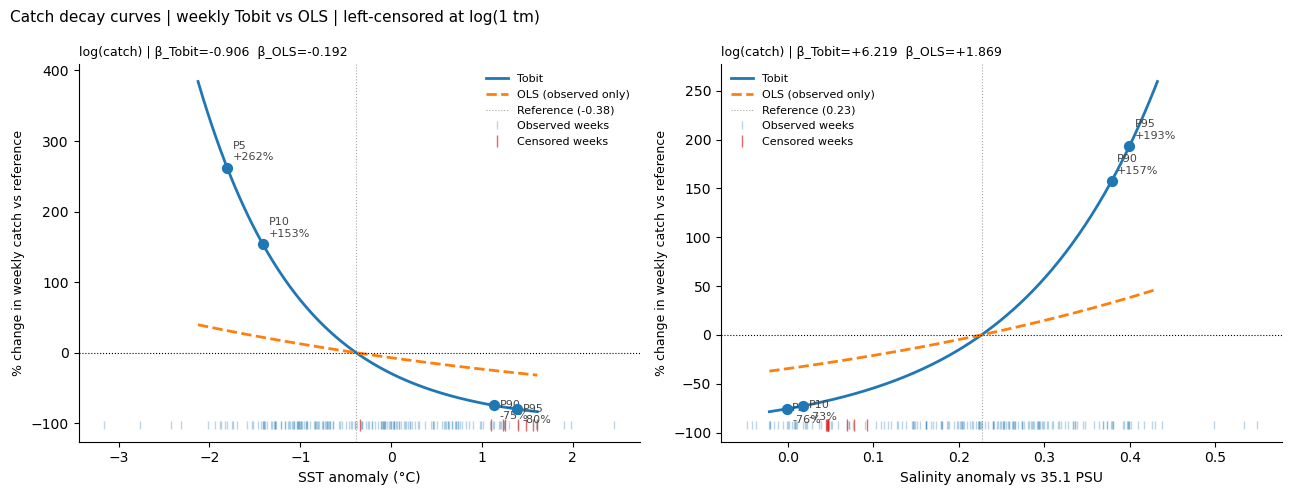

Saved → /home/jupyter-daniela/peru_catch_modeling/outputs/step8b_tobit_decay.png

=== Extreme-event catch decay summary ===

log(catch) ~ SST anomaly (°C)
  β_Tobit = -0.9057  (semi-elasticity: 1-unit → -59.6% catch change)
            Anomaly  % Δcatch (Tobit)  % Δcatch (OLS)
Percentile                                           
5            -1.805             262.1            31.3
10           -1.411             153.5            21.7
25           -1.024              78.5            13.0
50           -0.321              -5.6            -1.2
75            0.467             -53.7           -15.0
90            1.132             -74.7           -25.2
95            1.389             -79.9           -28.8

log(catch) ~ Salinity anomaly vs 35.1 PSU
  β_Tobit = +6.2185  (semi-elasticity: 1-unit → +50096.5% catch change)
            Anomaly  % Δcatch (Tobit)  % Δcatch (OLS)
Percentile                                           
5            -0.002             -75.8           -34.7
10           

In [21]:
TAB  = plt.cm.tab10.colors
PCTS = [5, 10, 25, 50, 75, 90, 95]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, r in zip(axes, [r_sst, r_sal]):
    x_col  = r['x_col']
    sub    = r['sub']
    cens   = r['cens']
    ref    = r['ref_val']

    x_range = np.linspace(sub[x_col].quantile(0.02),
                          sub[x_col].quantile(0.98), 300)
    y_tb    = (np.exp(r['beta_tb']  * (x_range - ref)) - 1) * 100
    y_ols   = (np.exp(r['beta_ols'] * (x_range - ref)) - 1) * 100

    ax.plot(x_range, y_tb,  color=TAB[0], lw=2,   label='Tobit')
    ax.plot(x_range, y_ols, color=TAB[1], lw=2, ls='--', label='OLS (observed only)')
    ax.axhline(0,    color='k',    lw=0.8, ls=':')
    ax.axvline(ref,  color='grey', lw=0.8, ls=':', alpha=0.7, label=f'Reference ({ref:.2f})')

    for pct, pv, dy_tb in zip(PCTS, r['pctiles'], r['pct_change_tb']):
        if pct in [5, 10, 90, 95]:
            col = TAB[3] if pct <= 10 else TAB[1]
            ax.scatter(pv, dy_tb, color=TAB[0], zorder=5, s=50)
            va  = 'bottom' if dy_tb >= 0 else 'top'
            ax.annotate(f'P{pct}\n{dy_tb:+.0f}%',
                        xy=(pv, dy_tb), xytext=(4, 4), textcoords='offset points',
                        fontsize=8, va=va, color='#444')

    obs_x  = sub.loc[~cens, x_col]
    cens_x = sub.loc[ cens, x_col]
    ymin, ymax = ax.get_ylim()
    rug_y  = ymin + 0.01 * (ymax - ymin)
    ax.plot(obs_x,  np.full(len(obs_x),  rug_y), '|',
            color=TAB[0], alpha=0.3, ms=6, label='Observed weeks')
    if len(cens_x):
        ax.plot(cens_x, np.full(len(cens_x), rug_y), '|',
                color=TAB[3], alpha=0.7, ms=9, label='Censored weeks')

    ax.set_xlabel(r['label'].split('~')[1].strip(), fontsize=10)
    ax.set_ylabel('% change in weekly catch vs reference', fontsize=9)
    ax.set_title(r['label'].split('~')[0].strip() + f' | β_Tobit={r["beta_tb"]:+.3f}  β_OLS={r["beta_ols"]:+.3f}',
                 loc='left', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Catch decay curves | weekly Tobit vs OLS | left-censored at log(1 tm)',
             x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / 'step8b_tobit_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {PLOTS / 'step8b_tobit_decay.png'}")

print("\n=== Extreme-event catch decay summary ===")
for r in [r_sst, r_sal]:
    print(f"\n{r['label']}")
    print(f"  β_Tobit = {r['beta_tb']:+.4f}  (semi-elasticity: 1-unit → "
          f"{(np.exp(r['beta_tb'])-1)*100:+.1f}% catch change)")
    pcts_tbl = pd.DataFrame({
        'Percentile': PCTS,
        'Anomaly':    np.round(r['pctiles'], 3),
        '% Δcatch (Tobit)': np.round(r['pct_change_tb'],  1),
        '% Δcatch (OLS)':   np.round(r['pct_change_ols'], 1),
    }).set_index('Percentile')
    print(pcts_tbl.to_string())

## Step 8c - Tobit β sensitivity analysis

Four diagnostics to assess how robust the Tobit slope is:
1. **Bootstrap** - resample censored weeks with replacement (observed fixed)
2. **Censoring threshold** - vary L from log(0.1 tm) to log(10 tm)
3. **Proportion of censored included** - gradually add 0→100 % of censored weeks
4. **Jackknife** - leave-one-censored-week-out

Then all four repeated **by season**.


  BOOTSTRAP — SST anomaly (°C)
  β_full=-0.9057 | mean=-0.9089 | 95%CI=[-1.0239, -0.6969]



  THRESHOLD — SST anomaly (°C)
  L=log(0.10 tm): β = -1.0548
  L=log(0.25 tm): β = -0.9954
  L=log(0.50 tm): β = -0.9506
  L=log(1.00 tm): β = -0.9057 ← baseline
  L=log(2.00 tm): β = -0.8610
  L=log(5.00 tm): β = -0.8018
  L=log(10.00 tm): β = -0.7572



  PROPORTION — SST anomaly (°C)
    0.0% censored: β = -0.1915
   10.0% censored: β = -0.2871
   20.0% censored: β = -0.3057
   30.0% censored: β = -0.4059
   40.0% censored: β = -0.4164
   50.0% censored: β = -0.6004
   60.0% censored: β = -0.5922
   70.0% censored: β = -0.8119
   80.0% censored: β = -0.7204
   90.0% censored: β = -0.8200
  100.0% censored: β = -0.9057



  JACKKNIFE — SST anomaly (°C)
  Drop 2019-W27: β = -0.9054  (Δ = +0.0003)
  Drop 2023-W24: β = -0.8047  (Δ = +0.1010)  *** influential
  Drop 2023-W25: β = -0.8264  (Δ = +0.0793)  *** influential
  Drop 2023-W26: β = -0.8190  (Δ = +0.0867)  *** influential
  Drop 2023-W27: β = -0.8083  (Δ = +0.0975)  *** influential
  Drop 2023-W28: β = -0.8121  (Δ = +0.0936)  *** influential
  Drop 2023-W29: β = -0.8024  (Δ = +0.1033)  *** influential
  Drop 2023-W30: β = -0.8200  (Δ = +0.0857)  *** influential



  BOOTSTRAP — Salinity anomaly (PSU)
  β_full=+6.2185 | mean=+6.2079 | 95%CI=[+5.9066, +6.5071]



  THRESHOLD — Salinity anomaly (PSU)
  L=log(0.10 tm): β = +7.1241
  L=log(0.25 tm): β = +6.7635
  L=log(0.50 tm): β = +6.4909
  L=log(1.00 tm): β = +6.2185 ← baseline
  L=log(2.00 tm): β = +5.9464
  L=log(5.00 tm): β = +5.5870
  L=log(10.00 tm): β = +5.3157



  PROPORTION — Salinity anomaly (PSU)
    0.0% censored: β = +1.8688
   10.0% censored: β = +2.4066
   20.0% censored: β = +3.0957
   30.0% censored: β = +3.0133
   40.0% censored: β = +3.6884
   50.0% censored: β = +3.9437
   60.0% censored: β = +4.6760
   70.0% censored: β = +5.1045
   80.0% censored: β = +5.1035
   90.0% censored: β = +5.6608
  100.0% censored: β = +6.2185



  JACKKNIFE — Salinity anomaly (PSU)
  Drop 2019-W27: β = +5.6648  (Δ = -0.5537)  *** influential
  Drop 2023-W24: β = +5.7612  (Δ = -0.4573)  *** influential
  Drop 2023-W25: β = +5.8091  (Δ = -0.4094)  *** influential
  Drop 2023-W26: β = +5.7357  (Δ = -0.4828)  *** influential
  Drop 2023-W27: β = +5.6680  (Δ = -0.5505)  *** influential
  Drop 2023-W28: β = +5.6663  (Δ = -0.5523)  *** influential
  Drop 2023-W29: β = +5.6656  (Δ = -0.5530)  *** influential
  Drop 2023-W30: β = +5.6608  (Δ = -0.5577)  *** influential


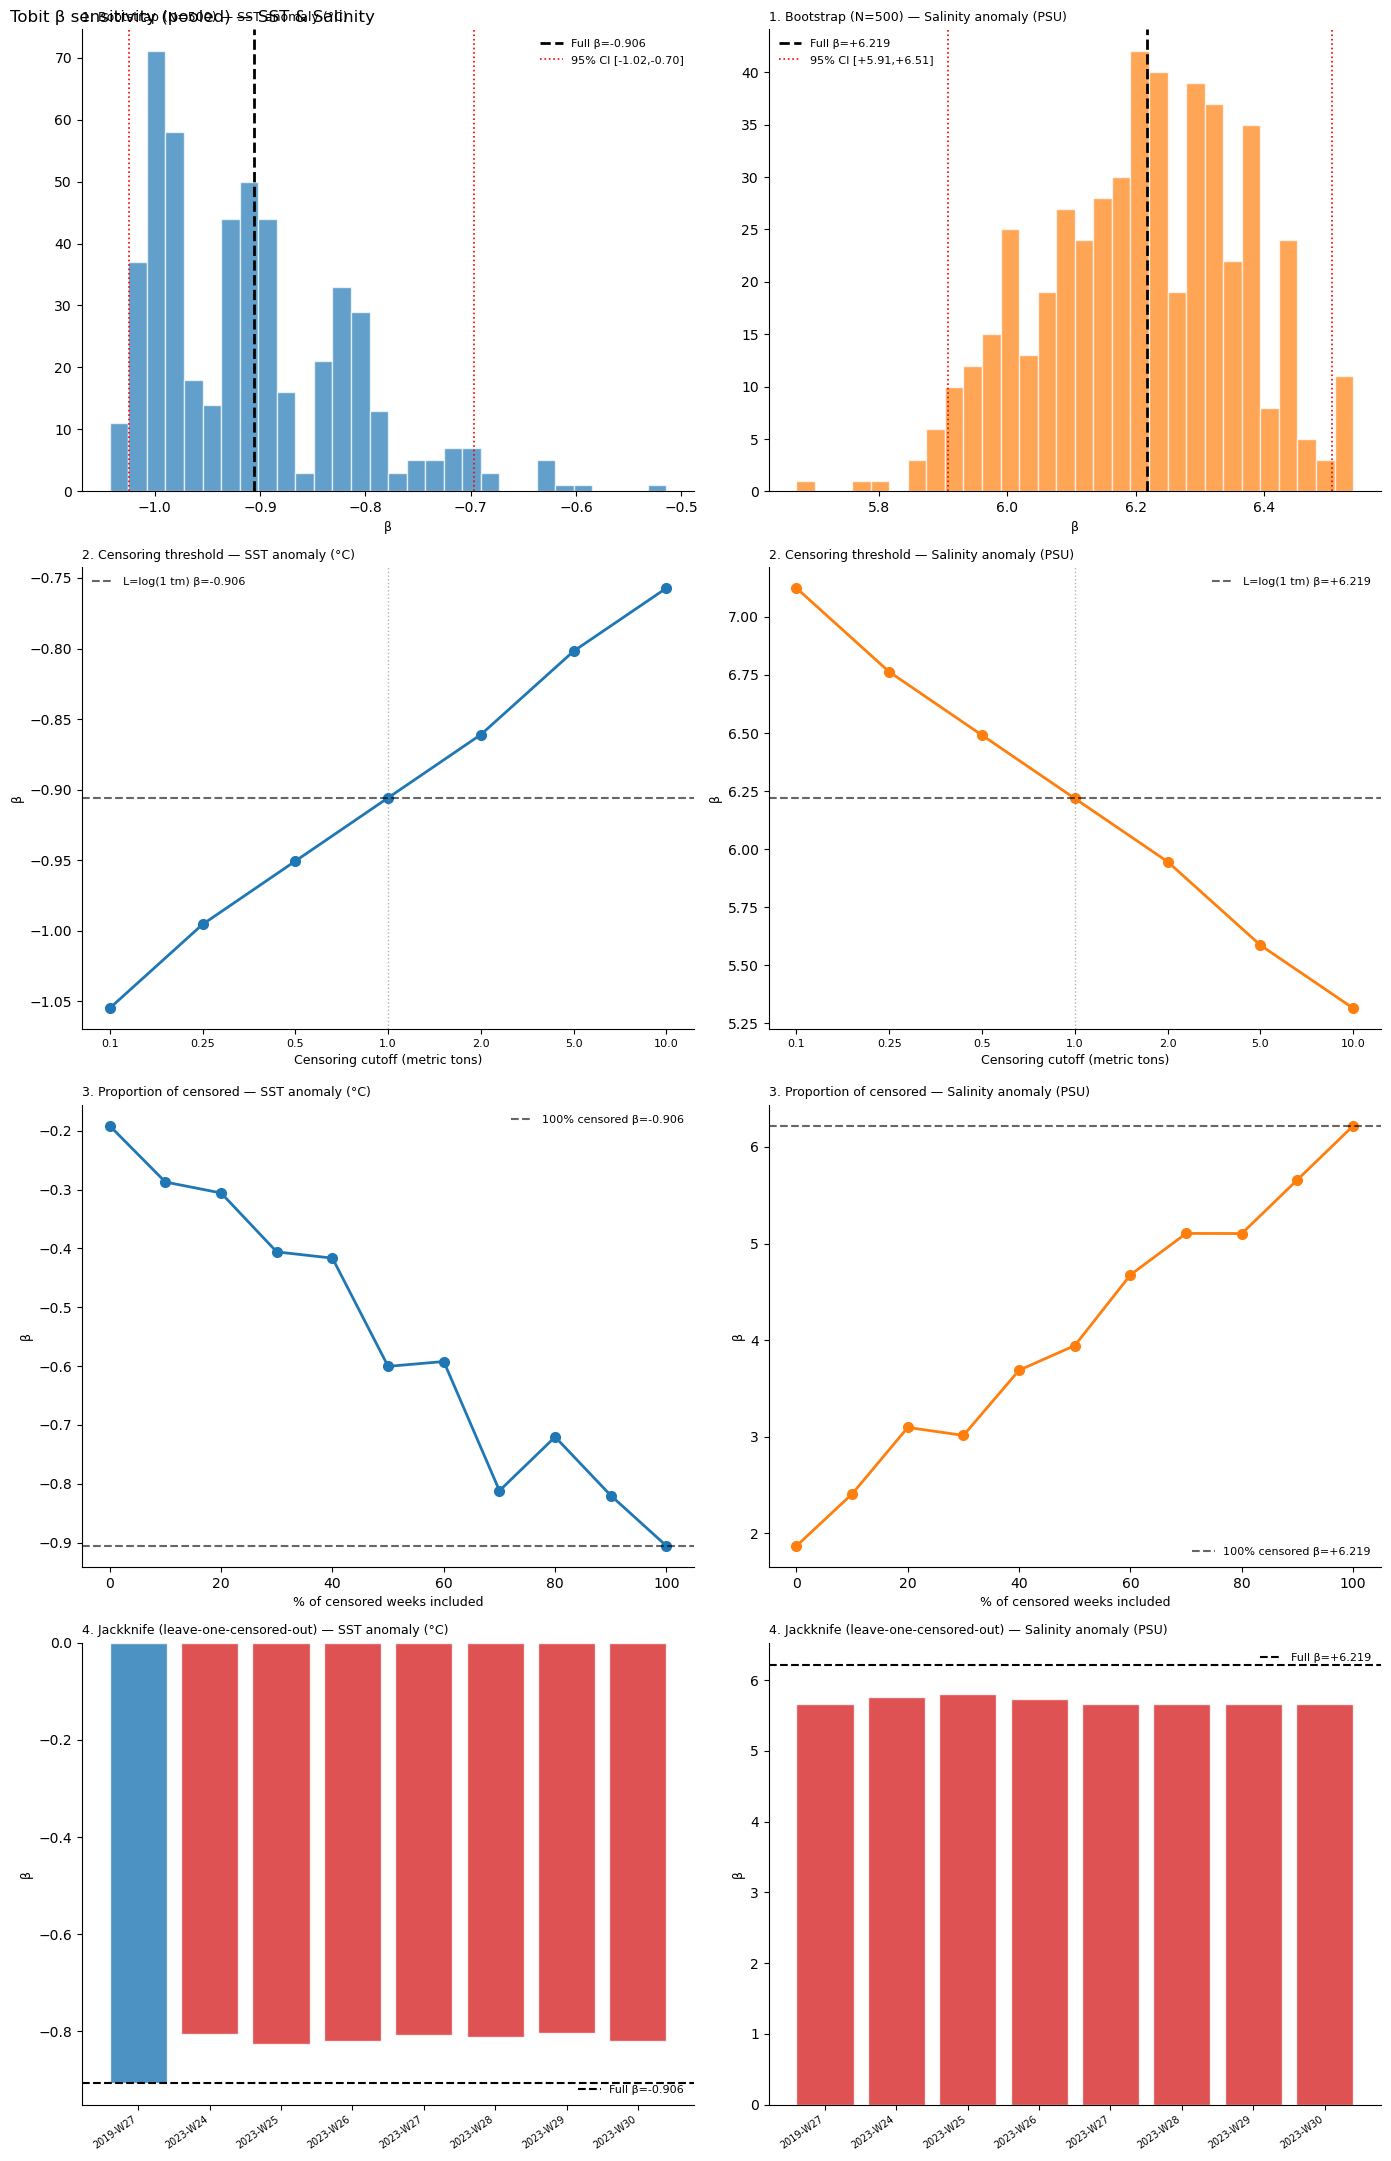


Saved → /home/jupyter-daniela/peru_catch_modeling/outputs/step8c_tobit_sensitivity_pooled.png


In [22]:
rng = np.random.default_rng(42)
PREDICTORS = [
    ('weekly_sst_anom',      'SST anomaly (°C)',        r_sst),
    ('weekly_sal_anom_ref35','Salinity anomaly (PSU)',   r_sal),
]

def fit_tobit_raw(x_vals, y_vals, cens_mask, L=L_CENS):
    """Fit univariate Tobit on raw arrays. Returns (beta, se, sigma) or NaNs on failure."""
    if cens_mask.sum() == len(cens_mask) or (~cens_mask).sum() < 3:
        return np.nan, np.nan, np.nan
    X = np.column_stack([np.ones(len(x_vals)), x_vals])
    y = y_vals.copy()
    y[cens_mask] = L
    obs_mask = ~cens_mask
    b0 = np.linalg.lstsq(X[obs_mask], y[obs_mask], rcond=None)[0]
    resid = y[obs_mask] - X[obs_mask] @ b0
    p0 = np.append(b0, np.log(resid.std() + 1e-6))
    try:
        res = minimize(tobit_nll, p0, args=(X, y, cens_mask, L),
                       method='L-BFGS-B', options={'maxiter': 5000, 'ftol': 1e-10})
        if not res.success:
            return np.nan, np.nan, np.nan
        beta_hat  = res.x[:-1]
        sigma_hat = np.exp(res.x[-1])
        eps   = 1e-5; n = len(res.x)
        nll_fn = lambda p: tobit_nll(p, X, y, cens_mask, L)
        grad0  = approx_fprime(res.x, nll_fn, eps)
        hess   = np.zeros((n, n))
        for i in range(n):
            xf = res.x.copy(); xf[i] += eps
            hess[i] = (approx_fprime(xf, nll_fn, eps) - grad0) / eps
        hess = (hess + hess.T) / 2
        vcov = np.linalg.pinv(hess)
        se   = np.sqrt(np.maximum(np.diag(vcov)[:-1], 0))
        return beta_hat[1], se[1], sigma_hat
    except Exception:
        return np.nan, np.nan, np.nan

fig, axes = plt.subplots(4, 2, figsize=(14, 22))

for col_idx, (x_col, x_label, r) in enumerate(PREDICTORS):
    sub       = r['sub'].copy()
    cens      = r['cens']
    beta_ref  = r['beta_tb']
    x_vals    = sub[x_col].values
    y_vals    = sub['log_weekly_catch'].fillna(L_CENS).values
    obs_idx   = np.where(~cens)[0]
    cens_idx  = np.where(cens)[0]

    N_BOOT = 500
    betas_boot = []
    for _ in range(N_BOOT):
        bc  = rng.choice(cens_idx, size=len(cens_idx), replace=True)
        idx = np.concatenate([obs_idx, bc])
        cm  = np.concatenate([np.zeros(len(obs_idx), bool), np.ones(len(bc), bool)])
        b, _, _ = fit_tobit_raw(x_vals[idx], y_vals[idx], cm)
        betas_boot.append(b)
    betas_boot = np.array(betas_boot)
    ci_lo, ci_hi = np.nanpercentile(betas_boot, [2.5, 97.5])

    ax = axes[0, col_idx]
    ax.hist(betas_boot[~np.isnan(betas_boot)], bins=30,
            color=TAB[col_idx], alpha=0.7, edgecolor='white')
    ax.axvline(beta_ref,  color='k',   lw=2,   ls='--', label=f'Full β={beta_ref:+.3f}')
    ax.axvline(ci_lo,     color='red', lw=1.2, ls=':')
    ax.axvline(ci_hi,     color='red', lw=1.2, ls=':', label=f'95% CI [{ci_lo:+.2f},{ci_hi:+.2f}]')
    ax.set_title(f'1. Bootstrap (N={N_BOOT}) — {x_label}', loc='left', fontsize=9)
    ax.set_xlabel('β', fontsize=9); ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    print(f"\n{'='*55}\n  BOOTSTRAP — {x_label}")
    print(f"  β_full={beta_ref:+.4f} | mean={np.nanmean(betas_boot):+.4f} | "
          f"95%CI=[{ci_lo:+.4f}, {ci_hi:+.4f}]")

    THRESH_TM  = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]
    THRESH_L   = [np.log(t) for t in THRESH_TM]
    betas_thr  = []
    for L_t in THRESH_L:
        cens_t = (sub['log_weekly_catch'].fillna(-np.inf) <= L_t).values
        y_t    = sub['log_weekly_catch'].fillna(L_t).values
        b, _, _ = fit_tobit_raw(x_vals, y_t, cens_t, L=L_t)
        betas_thr.append(b)

    ax = axes[1, col_idx]
    ax.plot(range(len(THRESH_TM)), betas_thr, 'o-', color=TAB[col_idx], lw=2, ms=7)
    ax.axhline(beta_ref, color='k', lw=1.5, ls='--', alpha=0.6, label=f'L=log(1 tm) β={beta_ref:+.3f}')
    ref_pos = THRESH_TM.index(1.0)
    ax.axvline(ref_pos, color='grey', lw=1, ls=':', alpha=0.6)
    ax.set_xticks(range(len(THRESH_TM)))
    ax.set_xticklabels([f'{t}' for t in THRESH_TM], fontsize=8)
    ax.set_xlabel('Censoring cutoff (metric tons)', fontsize=9)
    ax.set_ylabel('β', fontsize=9)
    ax.set_title(f'2. Censoring threshold — {x_label}', loc='left', fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    print(f"\n  THRESHOLD — {x_label}")
    for tm, b in zip(THRESH_TM, betas_thr):
        mark = ' ← baseline' if tm == 1.0 else ''
        print(f"  L=log({tm:4.2f} tm): β = {b:+.4f}{mark}")

    proportions = np.linspace(0, 1, 11)
    betas_prop  = []
    for prop in proportions:
        n_keep = int(round(prop * len(cens_idx)))
        if n_keep == 0:
            idx = obs_idx; cm = np.zeros(len(obs_idx), bool)
        else:
            kc  = rng.choice(cens_idx, size=n_keep, replace=False)
            idx = np.concatenate([obs_idx, kc])
            cm  = np.concatenate([np.zeros(len(obs_idx), bool), np.ones(n_keep, bool)])
        b, _, _ = fit_tobit_raw(x_vals[idx], y_vals[idx], cm)
        betas_prop.append(b)

    ax = axes[2, col_idx]
    ax.plot(proportions * 100, betas_prop, 'o-', color=TAB[col_idx], lw=2, ms=7)
    ax.axhline(beta_ref, color='k', lw=1.5, ls='--', alpha=0.6, label=f'100% censored β={beta_ref:+.3f}')
    ax.set_xlabel('% of censored weeks included', fontsize=9)
    ax.set_ylabel('β', fontsize=9)
    ax.set_title(f'3. Proportion of censored — {x_label}', loc='left', fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    print(f"\n  PROPORTION — {x_label}")
    for prop, b in zip(proportions, betas_prop):
        val = f"{b:+.4f}" if not np.isnan(b) else "NaN"
        print(f"  {prop*100:5.1f}% censored: β = {val}")

    betas_jack = []
    weeks_jack = []
    for leave_out in cens_idx:
        kc  = [c for c in cens_idx if c != leave_out]
        idx = np.concatenate([obs_idx, kc])
        cm  = np.concatenate([np.zeros(len(obs_idx), bool), np.ones(len(kc), bool)])
        b, _, _ = fit_tobit_raw(x_vals[idx], y_vals[idx], cm)
        betas_jack.append(b)
        weeks_jack.append(sub.iloc[leave_out]['year_week'])

    ax = axes[3, col_idx]
    colors_jack = [TAB[3] if abs(b - beta_ref) > 0.05 * abs(beta_ref) else TAB[col_idx]
                   for b in betas_jack]
    ax.bar(range(len(cens_idx)), betas_jack, color=colors_jack, alpha=0.8, edgecolor='white')
    ax.axhline(beta_ref, color='k', lw=1.5, ls='--', label=f'Full β={beta_ref:+.3f}')
    ax.set_xticks(range(len(cens_idx)))
    ax.set_xticklabels(weeks_jack, rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('β', fontsize=9)
    ax.set_title(f'4. Jackknife (leave-one-censored-out) — {x_label}', loc='left', fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    print(f"\n  JACKKNIFE — {x_label}")
    for wk, b in zip(weeks_jack, betas_jack):
        delta = b - beta_ref
        flag  = '  *** influential' if abs(delta) > 0.05 * abs(beta_ref) else ''
        print(f"  Drop {wk}: β = {b:+.4f}  (Δ = {delta:+.4f}){flag}")

fig.suptitle('Tobit β sensitivity (pooled) — SST & Salinity', x=0.01, ha='left', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS / 'step8c_tobit_sensitivity_pooled.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {PLOTS / 'step8c_tobit_sensitivity_pooled.png'}")



  BY-SEASON Tobit β — SST anomaly (°C)   (pooled β=-0.9057)
          n_obs  n_cens  beta_tobit      se  boot_ci_lo  boot_ci_hi  jk_max_Δ
season                                                                       
1ra 2016      6       0     -0.2153 +0.6164         NaN         NaN       NaN
1ra 2017      8       0     +0.2020 +0.7330         NaN         NaN       NaN
1ra 2018     12       0     -0.3103 +0.4925         NaN         NaN       NaN
1ra 2019     13       1     -0.1407 +2.3686     -0.1406     -0.1406   +0.5741
1ra 2020     11       0     +0.3460 +0.3605         NaN         NaN       NaN
1ra 2021     14       0     -0.0545 +0.2726         NaN         NaN       NaN
1ra 2022     12       0     -0.2177 +0.1731         NaN         NaN       NaN
1ra 2023      4       7    +14.7526 +8.6776    +13.6702    +15.3466   +1.3451
1ra 2024     10       0     -0.5164 +1.0727         NaN         NaN       NaN
2da 2015     10       0     -0.0063 +1.5446         NaN         NaN       NaN
2da


  BY-SEASON Tobit β — Salinity anomaly (PSU)   (pooled β=+6.2185)
          n_obs  n_cens  beta_tobit       se  boot_ci_lo  boot_ci_hi  jk_max_Δ
season                                                                        
1ra 2016      6       0    +15.8983 +11.3988         NaN         NaN       NaN
1ra 2017      8       0    -19.5769 +16.7222         NaN         NaN       NaN
1ra 2018     12       0     -7.5732  +4.2050         NaN         NaN       NaN
1ra 2019     13       1    +14.1698  +6.3908    +14.1698    +14.1698  +12.7138
1ra 2020     11       0     +7.0535  +1.5247         NaN         NaN       NaN
1ra 2021     14       0     +4.7062  +2.6307         NaN         NaN       NaN
1ra 2022     12       0     +1.5821  +1.1417         NaN         NaN       NaN
1ra 2023      4       7   +103.8211 +34.2363    +96.8168   +111.5509   +7.5356
1ra 2024     10       0     +0.2668  +9.4645         NaN         NaN       NaN
2da 2015     10       0    -10.7322 +18.5220         NaN        

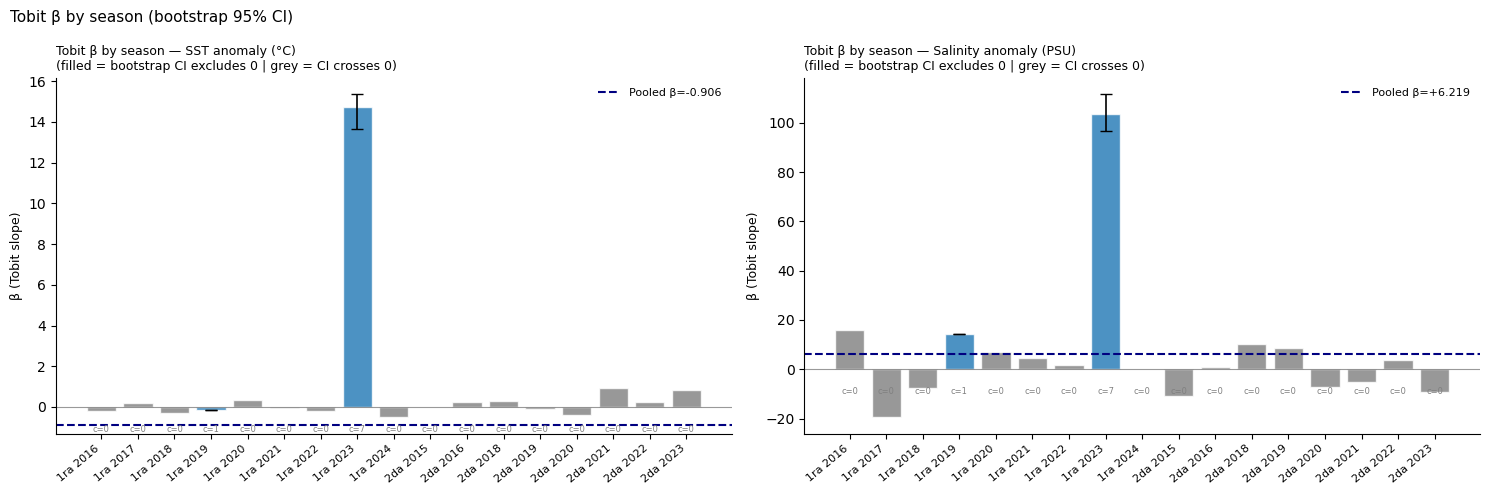


Saved → /home/jupyter-daniela/peru_catch_modeling/outputs/step8c_tobit_sensitivity_by_season.png


In [23]:
seasons = sorted(full_panel['season'].unique())
N_BOOT_S = 300

results_season = {}

for x_col, x_label, r_full in PREDICTORS:
    beta_pool = r_full['beta_tb']
    rows_boot = []
    rows_meta = []

    for season in seasons:
        sp = full_panel[full_panel['season'] == season].dropna(subset=[x_col]).copy()
        if len(sp) < 5:
            continue
        cens_s   = sp['censored'].values
        x_s      = sp[x_col].values
        y_s      = sp['log_weekly_catch'].fillna(L_CENS).values
        obs_s    = np.where(~cens_s)[0]
        cens_s_i = np.where(cens_s)[0]

        beta_s, se_s, _ = fit_tobit_raw(x_s, y_s, cens_s)

        bb = []
        if len(cens_s_i) > 0:
            for _ in range(N_BOOT_S):
                bc  = rng.choice(cens_s_i, size=len(cens_s_i), replace=True)
                idx = np.concatenate([obs_s, bc])
                cm  = np.concatenate([np.zeros(len(obs_s), bool), np.ones(len(bc), bool)])
                bv, _, _ = fit_tobit_raw(x_s[idx], y_s[idx], cm)
                bb.append(bv)
        bb = np.array(bb) if bb else np.array([np.nan])
        ci_lo_s = np.nanpercentile(bb, 2.5)  if not np.all(np.isnan(bb)) else np.nan
        ci_hi_s = np.nanpercentile(bb, 97.5) if not np.all(np.isnan(bb)) else np.nan

        jk_deltas = []
        if len(cens_s_i) > 0:
            for lo in cens_s_i:
                kc  = [c for c in cens_s_i if c != lo]
                idx = np.concatenate([obs_s, kc]) if kc else obs_s
                cm  = np.concatenate([np.zeros(len(obs_s), bool),
                                       np.ones(len(kc), bool)]) if kc else np.zeros(len(obs_s), bool)
                bv, _, _ = fit_tobit_raw(x_s[idx], y_s[idx], cm)
                jk_deltas.append(bv - beta_s if not np.isnan(bv) else np.nan)
        jk_max_delta = np.nanmax(np.abs(jk_deltas)) if jk_deltas else np.nan

        rows_boot.append({'season': season, 'beta': beta_s,
                          'ci_lo': ci_lo_s, 'ci_hi': ci_hi_s})
        rows_meta.append({
            'season':      season,
            'n_weeks':     len(sp),
            'n_obs':       int((~cens_s).sum()),
            'n_cens':      int(cens_s.sum()),
            'beta_tobit':  beta_s,
            'se':          se_s,
            'boot_ci_lo':  ci_lo_s,
            'boot_ci_hi':  ci_hi_s,
            'jk_max_Δ':    jk_max_delta,
        })

    df_meta = pd.DataFrame(rows_meta).set_index('season')
    results_season[x_col] = {'meta': df_meta, 'beta_pool': beta_pool}

    print(f"\n{'='*65}")
    print(f"  BY-SEASON Tobit β — {x_label}   (pooled β={beta_pool:+.4f})")
    print(f"{'='*65}")
    print(df_meta[['n_obs','n_cens','beta_tobit','se','boot_ci_lo','boot_ci_hi','jk_max_Δ']]
          .to_string(float_format=lambda v: f'{v:+.4f}' if not np.isnan(v) else '  NaN '))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (x_col, x_label, r_full) in zip(axes, PREDICTORS):
    res       = results_season[x_col]
    df_m      = res['meta'].reset_index()
    beta_pool = res['beta_pool']

    seas  = df_m['season'].tolist()
    betas = df_m['beta_tobit'].values.astype(float)
    lo    = df_m['boot_ci_lo'].values.astype(float)
    hi    = df_m['boot_ci_hi'].values.astype(float)
    x_pos = np.arange(len(seas))

    colors_s = []
    for b, l, h in zip(betas, lo, hi):
        if np.isnan(b):
            colors_s.append('lightgrey')
        elif not np.isnan(l) and not np.isnan(h) and ((l > 0 and h > 0) or (l < 0 and h < 0)):
            colors_s.append(TAB[0])
        else:
            colors_s.append(TAB[7])

    ax.bar(x_pos, np.where(np.isnan(betas), 0, betas),
           color=colors_s, alpha=0.8, edgecolor='white', zorder=2)

    valid = ~(np.isnan(betas) | np.isnan(lo) | np.isnan(hi))
    if valid.any():
        yerr_lo = np.clip(betas[valid] - lo[valid], 0, None)
        yerr_hi = np.clip(hi[valid] - betas[valid], 0, None)
        ax.errorbar(x_pos[valid], betas[valid],
                    yerr=[yerr_lo, yerr_hi],
                    fmt='none', color='black', capsize=4, lw=1.2, zorder=3)

    ax.axhline(0,         color='k',    lw=0.8, ls='-',  alpha=0.4)
    ax.axhline(beta_pool, color='navy', lw=1.5, ls='--', label=f'Pooled β={beta_pool:+.3f}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(seas, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('β (Tobit slope)', fontsize=9)
    ax.set_title(f'Tobit β by season — {x_label}\n'
                 f'(filled = bootstrap CI excludes 0 | grey = CI crosses 0)', loc='left', fontsize=9)
    ax.legend(frameon=False, fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    for xp, row in zip(x_pos, df_m.itertuples()):
        if not np.isnan(row.beta_tobit):
            ax.annotate(f'c={row.n_cens}', xy=(xp, 0),
                        xytext=(0, -18), textcoords='offset points',
                        ha='center', fontsize=6, color='grey')

fig.suptitle('Tobit β by season (bootstrap 95% CI)', x=0.01, ha='left', fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / 'step8c_tobit_sensitivity_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved → {PLOTS / 'step8c_tobit_sensitivity_by_season.png'}")


## Step 9 - Composite habitat index
Equal-weight and data-driven versions. Tercile boxplots and Kruskal-Wallis test per ENSO phase.

Data-driven weights: SST=0.024  CHL=-0.012  SAL=-2.894

=== Equal-weight HI — Kruskal-Wallis (pooled) ===
  KW H=2.47  p=0.2912
  poor: mean=95,121  median=77,341  N=58
  moderate: mean=107,860  median=105,551  N=57
  good: mean=95,744  median=92,735  N=58
  Per-phase KW (Equal-weight HI):
    nino: H=1.80  p=0.4061  N=54
    neutral: H=0.53  p=0.7675  N=70
    nina: H=0.16  p=0.9249  N=49

=== Data-driven HI — Kruskal-Wallis (pooled) ===
  KW H=6.15  p=0.0461
  poor: mean=111,250  median=107,358  N=58
  moderate: mean=102,810  median=97,928  N=57
  good: mean=84,578  median=79,339  N=58
  Per-phase KW (Data-driven HI):
    nino: H=5.60  p=0.0609  N=54
    neutral: H=0.15  p=0.9281  N=70
    nina: H=4.38  p=0.1120  N=49


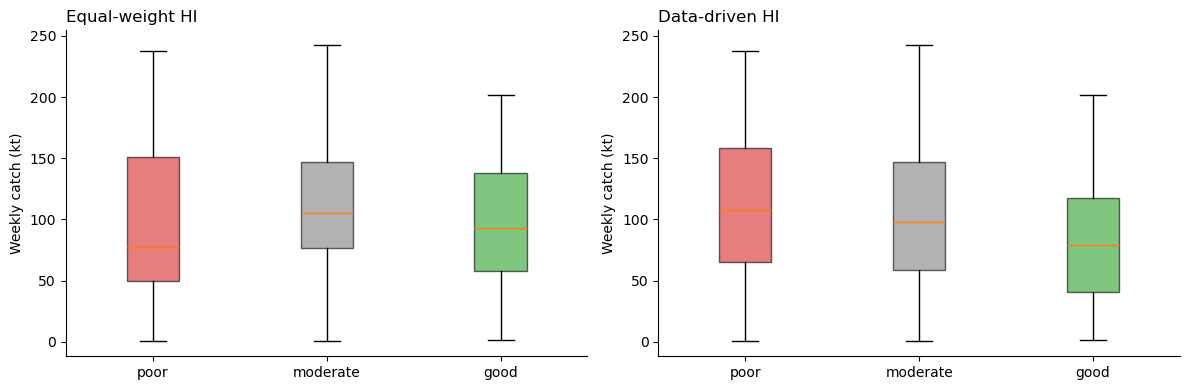

In [24]:
def zsc(s): return (s - s.mean()) / s.std()

wpos['hi_equal'] = (-zsc(wpos['weekly_sst_anom'])
                    + zsc(wpos['weekly_log_chl_anom'])
                    - zsc(wpos['weekly_sal_anom']))

w7a_coefs = mw7a.params
w_sst = w7a_coefs.get('weekly_sst_anom', 0)
w_chl = w7a_coefs.get('weekly_log_chl_anom', 0)
w_sal = w7a_coefs.get('weekly_sal_anom', 0)
print(f"Data-driven weights: SST={w_sst:.3f}  CHL={w_chl:.3f}  SAL={w_sal:.3f}")

wpos['hi_wtd'] = (w_sst * zsc(wpos['weekly_sst_anom'])
                + w_chl * zsc(wpos['weekly_log_chl_anom'])
                + w_sal * zsc(wpos['weekly_sal_anom']))

for hi_col, label in [('hi_equal','Equal-weight HI'),('hi_wtd','Data-driven HI')]:
    wpos[hi_col+'_q'] = pd.qcut(wpos[hi_col], 3, labels=['poor','moderate','good'])
    print(f"\n=== {label} — Kruskal-Wallis (pooled) ===")
    groups = [wpos[wpos[hi_col+'_q']==q]['weekly_catch_tm'].values for q in ['poor','moderate','good']]
    H, p = kruskal(*[g for g in groups if len(g)>0])
    print(f"  KW H={H:.2f}  p={p:.4f}")
    for q in ['poor','moderate','good']:
        g = wpos[wpos[hi_col+'_q']==q]['weekly_catch_tm']
        print(f"  {q}: mean={g.mean():,.0f}  median={g.median():,.0f}  N={len(g)}")
    print(f"  Per-phase KW ({label}):")
    for phase in ['nino','neutral','nina']:
        sub_p = wpos[wpos['enso_phase']==phase]
        if len(sub_p) < 15: continue
        grps = [sub_p[sub_p[hi_col+'_q']==q]['weekly_catch_tm'].values for q in ['poor','moderate','good']]
        grps = [g for g in grps if len(g)>1]
        if len(grps) < 2: continue
        H2, p2 = kruskal(*grps)
        print(f"    {phase}: H={H2:.2f}  p={p2:.4f}  N={len(sub_p)}")

TAB = plt.cm.tab10.colors
QCOLORS = [TAB[3], TAB[7], TAB[2]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hi_col, label in zip(axes, ['hi_equal','hi_wtd'], ['Equal-weight HI','Data-driven HI']):
    data_by_q = [wpos[wpos[hi_col+'_q']==q]['weekly_catch_tm'].values/1e3 for q in ['poor','moderate','good']]
    bp = ax.boxplot(data_by_q, labels=['poor','moderate','good'], showfliers=False, patch_artist=True)
    for patch, col in zip(bp['boxes'], QCOLORS):
        patch.set_facecolor(col); patch.set_alpha(0.6)
    ax.set_title(label, loc='left')
    ax.set_ylabel('Weekly catch (kt)')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS / 'step9_habitat.png', dpi=120)
plt.show()


## Step 10 - Threshold identification: percentile-based trigger (both tails)


=== 10a — SST anomaly two-tail ===
tail  percentile  threshold  n_flagged  mean_flagged  mean_unflagged  sep_ratio  freq_pct
cold          10     -1.411         18        116139           97598      1.190      10.4
cold          15     -1.285         26        116603           96507      1.208      15.0
cold          20     -1.123         35        115990           95352      1.216      20.2
cold          25     -1.026         44        112588           95072      1.184      25.4
cold          30     -0.935         52        115961           92465      1.254      30.1
warm          70      0.170         52         84089          106161      0.792      30.1
warm          75      0.439         44         82670          105277      0.785      25.4
warm          80      0.630         35         74750          105811      0.706      20.2
warm          85      0.741         26         68322          105046      0.650      15.0
warm          90      1.044         18         62444          10

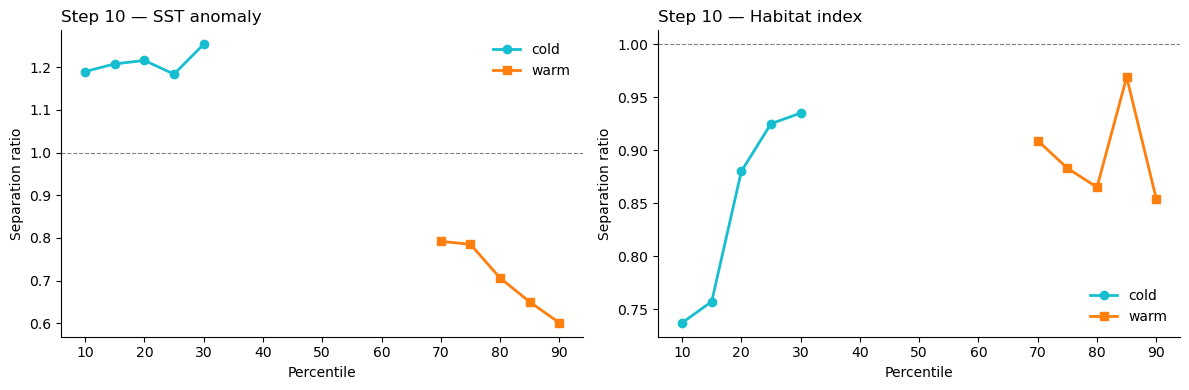

In [25]:
COLD_PCTS = [10,15,20,25,30]
WARM_PCTS = [70,75,80,85,90]

def two_tail_search(data, sig_col, label):
    print(f"\n=== {label} ===")
    rows = []
    for pct in COLD_PCTS:
        thr = data[sig_col].quantile(pct/100)
        flagged   = data[data[sig_col] <= thr]['weekly_catch_tm']
        unflagged = data[data[sig_col] >  thr]['weekly_catch_tm']
        sep = flagged.mean()/unflagged.mean() if len(unflagged)>0 and unflagged.mean()>0 else np.nan
        rows.append({'tail':'cold','percentile':pct,'threshold':round(thr,3),
                     'n_flagged':len(flagged),'mean_flagged':round(flagged.mean()),
                     'mean_unflagged':round(unflagged.mean()),'sep_ratio':round(sep,3),
                     'freq_pct':round(len(flagged)/len(data)*100,1)})
    for pct in WARM_PCTS:
        thr = data[sig_col].quantile(pct/100)
        flagged   = data[data[sig_col] >= thr]['weekly_catch_tm']
        unflagged = data[data[sig_col] <  thr]['weekly_catch_tm']
        sep = flagged.mean()/unflagged.mean() if len(unflagged)>0 and unflagged.mean()>0 else np.nan
        rows.append({'tail':'warm','percentile':pct,'threshold':round(thr,3),
                     'n_flagged':len(flagged),'mean_flagged':round(flagged.mean()),
                     'mean_unflagged':round(unflagged.mean()),'sep_ratio':round(sep,3),
                     'freq_pct':round(len(flagged)/len(data)*100,1)})
    tbl = pd.DataFrame(rows)
    print(tbl.to_string(index=False))
    return tbl

tbl10_sst = two_tail_search(wpos, 'weekly_sst_anom', '10a — SST anomaly two-tail')
tbl10_hi  = two_tail_search(wpos, 'hi_equal',        '10d — Habitat index two-tail')

TAB = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tbl, title in zip(axes, [tbl10_sst, tbl10_hi], ['SST anomaly', 'Habitat index']):
    for tail, col, marker in [('cold', TAB[9], 'o'), ('warm', TAB[1], 's')]:
        sub = tbl[tbl['tail']==tail]
        ax.plot(sub['percentile'], sub['sep_ratio'], marker=marker, color=col, label=tail, lw=2)
    ax.axhline(1.0, color='grey', ls='--', lw=0.8)
    ax.set_xlabel('Percentile')
    ax.set_ylabel('Separation ratio')
    ax.set_title(f'Step 10 — {title}', loc='left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(PLOTS / 'step10_sep_ratio.png', dpi=120)
plt.show()


In [26]:
best_cold_sst = tbl10_sst[tbl10_sst['tail']=='cold'].sort_values('sep_ratio',ascending=False).iloc[0]
best_warm_sst = tbl10_sst[tbl10_sst['tail']=='warm'].sort_values('sep_ratio',ascending=False).iloc[0]

cold_thr = best_cold_sst['threshold']
warm_thr = best_warm_sst['threshold']

in_band   = wpos[(wpos['weekly_sst_anom'] > cold_thr) & (wpos['weekly_sst_anom'] < warm_thr)]
adv_cold  = wpos[wpos['weekly_sst_anom'] <= cold_thr]
adv_warm  = wpos[wpos['weekly_sst_anom'] >= warm_thr]

total = len(wpos)
print("=== 10b — Interval trigger (SST anomaly) ===")
print(f"Good band: ({cold_thr:.3f}, {warm_thr:.3f})")
print(f"  In good band   : {len(in_band):3d} weeks = {len(in_band)/total*100:.1f}%  mean catch={in_band['weekly_catch_tm'].mean():,.0f}")
print(f"  Adverse cold   : {len(adv_cold):3d} weeks = {len(adv_cold)/total*100:.1f}%  mean catch={adv_cold['weekly_catch_tm'].mean():,.0f}")
print(f"  Adverse warm   : {len(adv_warm):3d} weeks = {len(adv_warm)/total*100:.1f}%  mean catch={adv_warm['weekly_catch_tm'].mean():,.0f}")


=== 10b — Interval trigger (SST anomaly) ===
Good band: (-0.935, 0.170)
  In good band   :  69 weeks = 39.9%  mean catch=98,777
  Adverse cold   :  52 weeks = 30.1%  mean catch=115,961
  Adverse warm   :  52 weeks = 30.1%  mean catch=84,089


In [27]:
print("=== 10c — ENSO-conditioned SST thresholds ===")
for phase in ['nino','neutral','nina']:
    sub = wpos[wpos['enso_phase']==phase]
    if len(sub) < 15:
        print(f"  {phase}: too few ({len(sub)}) — skipped")
        continue
    rows = []
    for pct in COLD_PCTS:
        thr = sub['weekly_sst_anom'].quantile(pct/100)
        flagged   = sub[sub['weekly_sst_anom'] <= thr]['weekly_catch_tm']
        unflagged = sub[sub['weekly_sst_anom'] >  thr]['weekly_catch_tm']
        sep = flagged.mean()/unflagged.mean() if len(unflagged)>0 and unflagged.mean()>0 else np.nan
        rows.append({'pct':pct,'threshold':round(thr,3),'sep_ratio':round(sep,3),'N_flagged':len(flagged)})
    print(f"\n  {phase.upper()} (N={len(sub)}):")
    print(pd.DataFrame(rows).to_string(index=False))


=== 10c — ENSO-conditioned SST thresholds ===

  NINO (N=54):
 pct  threshold  sep_ratio  N_flagged
  10     -0.422      1.364          6
  15     -0.328      1.565          8
  20     -0.154      1.690         11
  25      0.063      1.566         14
  30      0.153      1.421         16

  NEUTRAL (N=70):
 pct  threshold  sep_ratio  N_flagged
  10     -1.366      1.003          7
  15     -1.275      1.234         11
  20     -1.096      1.255         14
  25     -1.024      1.197         18
  30     -0.993      1.340         21

  NINA (N=49):
 pct  threshold  sep_ratio  N_flagged
  10     -1.871      1.204          5
  15     -1.707      1.095          8
  20     -1.492      1.088         10
  25     -1.409      1.101         13
  30     -1.360      1.060         15


In [28]:
print("=== 10e — Payout structure sketch ===")

for sig_col, tbl, label in [
    ('weekly_sst_anom', tbl10_sst, 'SST anomaly'),
    ('hi_equal',        tbl10_hi,  'Habitat index (equal-weight)'),
]:
    best = tbl[tbl['tail']=='cold'].sort_values('sep_ratio', ascending=False).iloc[0]
    pct_val = int(best['percentile'])
    thr_val = float(best['threshold'])

    triggered   = wpos[wpos[sig_col] <= thr_val]
    untriggered = wpos[wpos[sig_col] >  thr_val]
    baseline    = wpos['weekly_catch_tm'].mean()
    loss        = baseline - triggered['weekly_catch_tm'].mean()
    loss_pct    = loss / baseline * 100

    print(f"\n  Trigger: {label} <= {thr_val:.3f} ({pct_val}th percentile)")
    print(f"  Historical frequency : {len(triggered)}/{len(wpos)} weeks = {len(triggered)/len(wpos)*100:.1f}%")
    print(f"  Mean catch triggered : {triggered['weekly_catch_tm'].mean():,.0f} tm")
    print(f"  Mean catch baseline  : {baseline:,.0f} tm")
    print(f"  Mean catch loss      : {loss:,.0f} tm = {loss_pct:.1f}% below baseline")

    print(f"  Activation by ENSO phase:")
    for phase in ['nino','neutral','nina']:
        sub_p = wpos[wpos['enso_phase']==phase]
        if len(sub_p) == 0:
            continue
        trig_p = sub_p[sub_p[sig_col] <= thr_val]
        print(f"    {phase:8s}: {len(trig_p)}/{len(sub_p)} weeks = {len(trig_p)/len(sub_p)*100:.1f}%")


=== 10e — Payout structure sketch ===

  Trigger: SST anomaly <= -0.935 (30th percentile)
  Historical frequency : 52/173 weeks = 30.1%
  Mean catch triggered : 115,961 tm
  Mean catch baseline  : 99,527 tm
  Mean catch loss      : -16,433 tm = -16.5% below baseline
  Activation by ENSO phase:
    nino    : 1/54 weeks = 1.9%
    neutral : 22/70 weeks = 31.4%
    nina    : 29/49 weeks = 59.2%

  Trigger: Habitat index (equal-weight) <= -0.643 (30th percentile)
  Historical frequency : 52/173 weeks = 30.1%
  Mean catch triggered : 94,880 tm
  Mean catch baseline  : 99,527 tm
  Mean catch loss      : 4,647 tm = 4.7% below baseline
  Activation by ENSO phase:
    nino    : 26/54 weeks = 48.1%
    neutral : 16/70 weeks = 22.9%
    nina    : 10/49 weeks = 20.4%
